In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from collections import defaultdict
import matplotlib
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import linregress
from scipy.optimize import linprog, linear_sum_assignment
from sklearn.metrics.pairwise import cosine_similarity
import warnings
import pickle as pkl
import os
import math
warnings.simplefilter("ignore")

In [2]:
from mtu_plots import graph_metrics_and_models, transform_relative_to_ideal
from mtu_utils import (
    get_inter_user_metrics,
    get_intra_user_metrics,
    get_sim_users_pairs,
)
print(matplotlib.__version__)

3.6.3


In [13]:
DEBUG = True

In [14]:
# graphing
plt.style.use('seaborn-whitegrid')
plt.rcParams.update({'font.size': 14})

# readable legend keys
id_to_readable = {
    "ideal": "Ideal",
    "content": "Content Filtering",
    "condent_reduced": "Reduced Attrs Content Filtering",
    "pop": "Popularity",
    "mf" : "Matrix Factorization",
    "sf": "Social Filtering", 
    "random": "Random"
}

In [15]:
folder_paths = ["2_metrics_results\\results_2"]

In [16]:
final_results = defaultdict(lambda: defaultdict(list))
for folder_path in folder_paths:
    filepath = os.path.join(folder_path, "sim_results.pkl")
    results = pkl.load(open(filepath, "rb"))
    for metric_name, v in results.items():
        for model_name, metric_vals in v.items():
            final_results[metric_name][model_name] += np.array(metric_vals).tolist()

In [17]:
user_prefs = np.array(final_results['user_prefs']['all'])
item_attrs = np.array(final_results['item_attrs']['all'])

In [18]:
interactions = dict()
for mo in id_to_readable.keys():
    interactions[mo] = np.array(final_results['interaction_history'][mo])
    interactions[mo] = np.transpose(interactions[mo].reshape(interactions[mo].shape[:-1]), axes=[0,2,1])

In [19]:
colors = dict()
colors['condent_reduced'] = 'tab:green'
colors['pop'] = 'tab:red'
colors['sf'] = 'tab:brown'
colors['content'] = 'tab:orange'
colors['mf'] = 'tab:purple'
colors['ideal'] = 'tab:blue'
colors['random'] = 'tab:pink'

# Métricas

## Jaccards

In [20]:
mean_Jacc_sim = dict()
ideal_mean_Jacc_sim = dict()
for mo in interactions.keys():
    mean_Jacc_sim[mo] = []
    ideal_mean_Jacc_sim[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        re2 = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_indices = interactions[mo][i]
        user_iter_indices_ideal = interactions['ideal'][i]
        for j in range(user_iter_indices.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            user_jiter_indices = user_iter_indices[:,:(j+1)]
            user_jiter_indices_ideal = user_iter_indices_ideal[:,:(j+1)]
            nearest_users = get_sim_users_pairs(mean_user_attrs)
            jacc = 0
            ideal_jacc = 0
            for p in nearest_users:
                setp0 = set(user_jiter_indices[p[0]])
                setp1 = set(user_jiter_indices[p[1]])
                jacc += len(setp0.intersection(setp1)) / len(setp0.union(setp1)) / len(nearest_users)

                ideal_setp0 = set(user_jiter_indices_ideal[p[0]])
                ideal_setp1 = set(user_jiter_indices_ideal[p[1]])
                ideal_jacc += len(ideal_setp0.intersection(ideal_setp1)) / len(ideal_setp0.union(ideal_setp1)) / len(nearest_users)

            re.append(jacc)
            re2.append(ideal_jacc)
        mean_Jacc_sim[mo].append(re)
        ideal_mean_Jacc_sim[mo].append(re2)
    mean_Jacc_sim[mo] = np.array(mean_Jacc_sim[mo])
    ideal_mean_Jacc_sim[mo] = np.array(ideal_mean_Jacc_sim[mo])

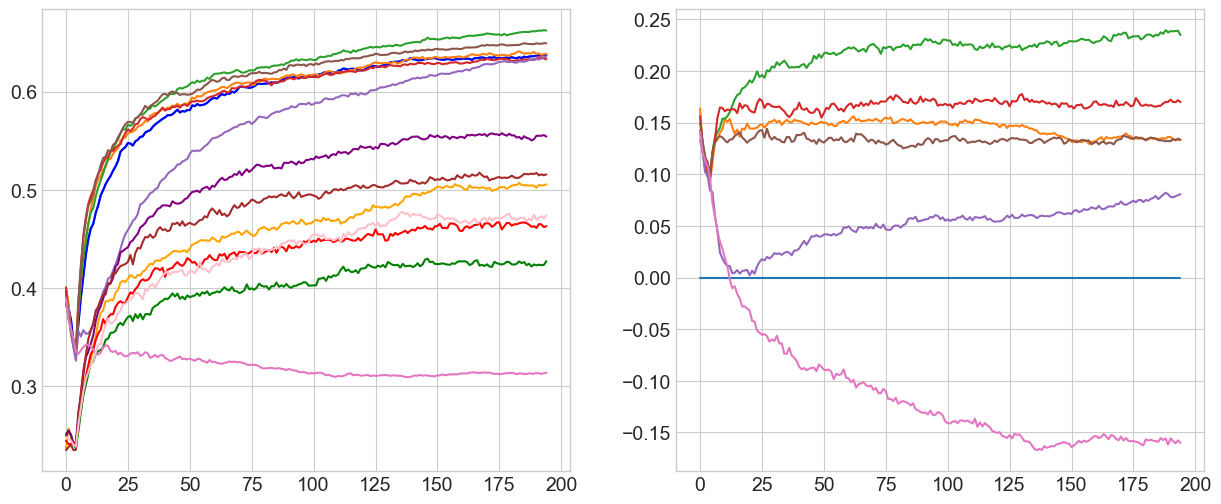

In [21]:
plt.figure(figsize=(15,6))
for mo in interactions.keys():
    plt.subplot(1, 2, 1)
    values = gaussian_filter1d((mean_Jacc_sim[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    values = gaussian_filter1d((ideal_mean_Jacc_sim[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo][4:])
    plt.subplot(1, 2, 2)
    values = gaussian_filter1d((mean_Jacc_sim[mo] - ideal_mean_Jacc_sim[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
plt.show()

## Inter-User Diversity

Some options

### RMSD

In [34]:
inter_RMSD = dict()
ideal_inter_RMSD = dict()
for mo in interactions.keys():
    inter_RMSD[mo] = []
    ideal_inter_RMSD[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        re2 = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_attrs_ideal = item_attrs[i].T[interactions['ideal'][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            ideal_mean_user_attrs = user_iter_attrs_ideal[:,:(j+1)].mean(axis=1)
            diffs = []
            nearest_users = get_sim_users_pairs(mean_user_attrs)
            pair_distance = 0
            ideal_pair_distance = 0
            for p in nearest_users:
                mean_pair_point = (mean_user_attrs[p[0]] + mean_user_attrs[p[1]]) / len(p)
                ideal_mean_pair_point = (ideal_mean_user_attrs[p[0]] + ideal_mean_user_attrs[p[1]]) / len(p)
                pair_distance += np.linalg.norm(mean_user_attrs[p[0]] - mean_pair_point)
                ideal_pair_distance += np.linalg.norm(ideal_mean_user_attrs[p[0]] - ideal_mean_pair_point)
            re.append(pair_distance / len(nearest_users))
            re2.append(ideal_pair_distance / len(nearest_users))
        inter_RMSD[mo].append(re)
        ideal_inter_RMSD[mo].append(re2)
    inter_RMSD[mo] = np.array(inter_RMSD[mo])
    ideal_inter_RMSD[mo] = np.array(ideal_inter_RMSD[mo])

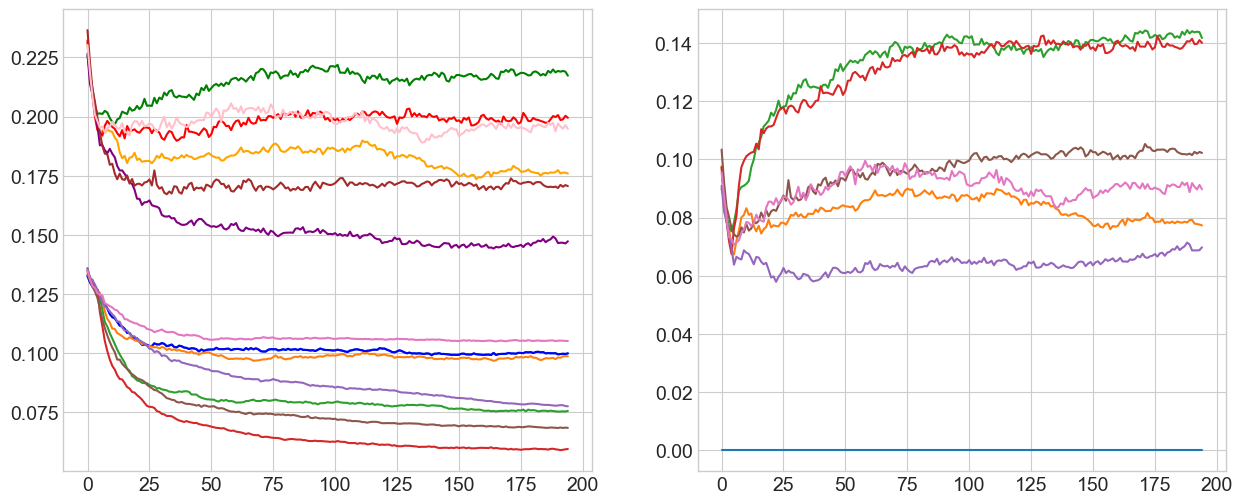

In [35]:
plt.figure(figsize=(15,6))
for mo in interactions.keys():
    plt.subplot(1, 2, 1)
    values = gaussian_filter1d((inter_RMSD[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    values = gaussian_filter1d((ideal_inter_RMSD[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo][4:])
    plt.subplot(1, 2, 2)
    values = gaussian_filter1d((ideal_inter_RMSD[mo] - inter_RMSD[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
plt.show()

In [85]:
inter_RWMSD = dict()
ideal_inter_RWMSD = dict()
for mo in interactions.keys():
    inter_RWMSD[mo] = []
    ideal_inter_RWMSD[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        re2 = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_attrs_ideal = item_attrs[i].T[interactions['ideal'][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            ideal_mean_user_attrs = user_iter_attrs_ideal[:,:(j+1)].mean(axis=1)
            diffs = []
            nearest_users = get_sim_users_pairs(mean_user_attrs)
            pair_distance = 0
            ideal_pair_distance = 0
            for p in nearest_users:
                mean_pair_point = (mean_user_attrs[p[0]] + mean_user_attrs[p[1]]) / len(p)
                ideal_mean_pair_point = (ideal_mean_user_attrs[p[0]] + ideal_mean_user_attrs[p[1]]) / len(p)
                pair_distance += np.linalg.norm(mean_user_attrs[p[0]] - mean_pair_point)*((j+1)**0.5)
                ideal_pair_distance += np.linalg.norm(ideal_mean_user_attrs[p[0]] - ideal_mean_pair_point)*((j+1)**0.5)
            re.append(pair_distance / len(nearest_users))
            re2.append(ideal_pair_distance / len(nearest_users))
        inter_RWMSD[mo].append(re)
        ideal_inter_RWMSD[mo].append(re2)
    inter_RWMSD[mo] = np.array(inter_RWMSD[mo])
    ideal_inter_RWMSD[mo] = np.array(ideal_inter_RWMSD[mo])

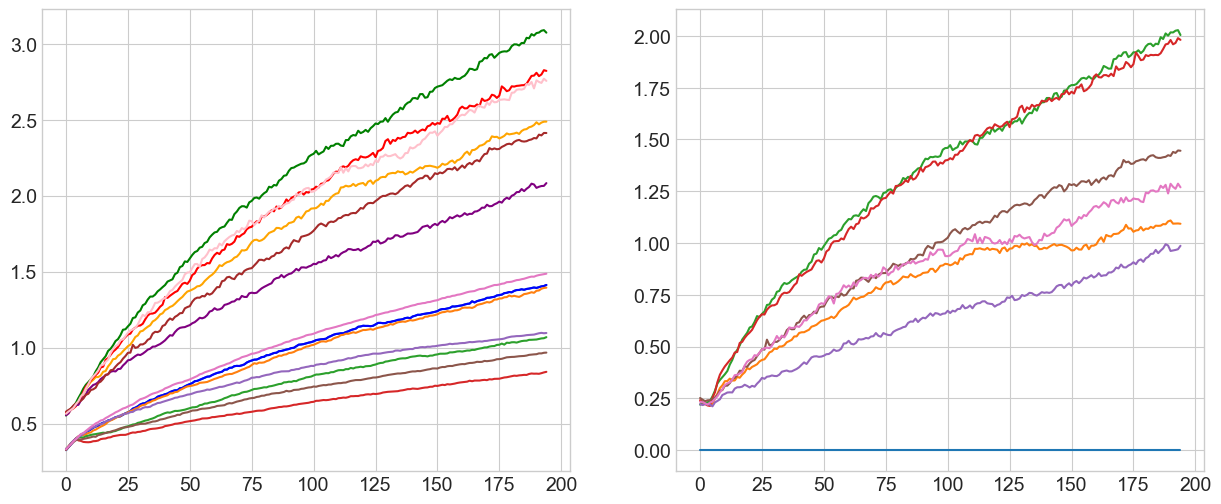

In [86]:
plt.figure(figsize=(15,6))
for mo in interactions.keys():
    plt.subplot(1, 2, 1)
    values = gaussian_filter1d((inter_RWMSD[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    values = gaussian_filter1d((ideal_inter_RWMSD[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo][4:])
    plt.subplot(1, 2, 2)
    values = gaussian_filter1d((ideal_inter_RWMSD[mo] - inter_RWMSD[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
plt.show()

In [87]:
inter_RWMSD_minus_one = dict()
ideal_inter_RWMSD_minus_one = dict()
for mo in interactions.keys():
    inter_RWMSD_minus_one[mo] = []
    ideal_inter_RWMSD_minus_one[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        re2 = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_attrs_ideal = item_attrs[i].T[interactions['ideal'][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            ideal_mean_user_attrs = user_iter_attrs_ideal[:,:(j+1)].mean(axis=1)
            diffs = []
            nearest_users = get_sim_users_pairs(mean_user_attrs)
            pair_distance = 0
            ideal_pair_distance = 0
            for p in nearest_users:
                mean_pair_point = (mean_user_attrs[p[0]] + mean_user_attrs[p[1]]) / len(p)
                ideal_mean_pair_point = (ideal_mean_user_attrs[p[0]] + ideal_mean_user_attrs[p[1]]) / len(p)
                pair_distance += np.linalg.norm(mean_user_attrs[p[0]] - mean_pair_point)*(((j+1)*len(p))**0.5)
                ideal_pair_distance += np.linalg.norm(ideal_mean_user_attrs[p[0]] - ideal_mean_pair_point)*(((j+1)*len(p))**0.5)
            re.append(pair_distance / len(nearest_users))
            re2.append(ideal_pair_distance / len(nearest_users))
        inter_RWMSD_minus_one[mo].append(re)
        ideal_inter_RWMSD_minus_one[mo].append(re2)
    inter_RWMSD_minus_one[mo] = np.array(inter_RWMSD_minus_one[mo])
    ideal_inter_RWMSD_minus_one[mo] = np.array(ideal_inter_RWMSD_minus_one[mo])

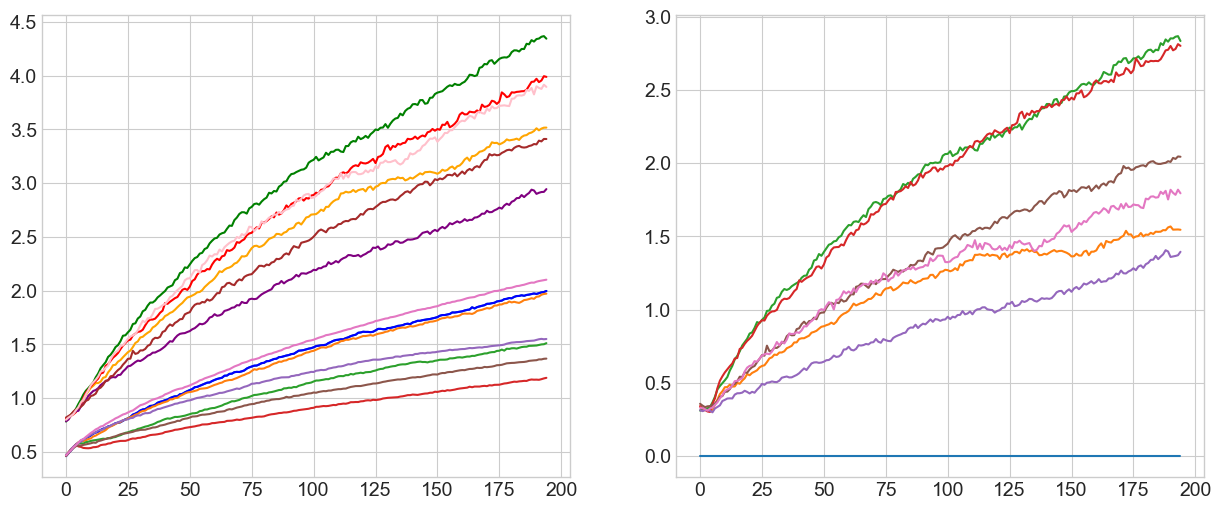

In [88]:
plt.figure(figsize=(15,6))
for mo in interactions.keys():
    plt.subplot(1, 2, 1)
    values = gaussian_filter1d((inter_RWMSD_minus_one[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    values = gaussian_filter1d((ideal_inter_RWMSD_minus_one[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo][4:])
    plt.subplot(1, 2, 2)
    values = gaussian_filter1d((ideal_inter_RWMSD_minus_one[mo] - inter_RWMSD_minus_one[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
plt.show()

In [43]:
inter_RMSD_minus_one = dict()
ideal_inter_RMSD_minus_one = dict()
for mo in interactions.keys():
    inter_RMSD_minus_one[mo] = []
    ideal_inter_RMSD_minus_one[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        re2 = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_attrs_ideal = item_attrs[i].T[interactions['ideal'][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            ideal_mean_user_attrs = user_iter_attrs_ideal[:,:(j+1)].mean(axis=1)
            diffs = []
            nearest_users = get_sim_users_pairs(mean_user_attrs)
            pair_distance = 0
            ideal_pair_distance = 0
            for p in nearest_users:
                mean_pair_point = (mean_user_attrs[p[0]] + mean_user_attrs[p[1]]) / len(p)
                ideal_mean_pair_point = (ideal_mean_user_attrs[p[0]] + ideal_mean_user_attrs[p[1]]) / len(p)
                pair_distance += np.linalg.norm(mean_user_attrs[p[0]] - mean_pair_point)*(len(p)**0.5)
                ideal_pair_distance += np.linalg.norm(ideal_mean_user_attrs[p[0]] - ideal_mean_pair_point)*(len(p)**0.5)
            re.append(pair_distance / len(nearest_users))
            re2.append(ideal_pair_distance / len(nearest_users))
        inter_RMSD_minus_one[mo].append(re)
        ideal_inter_RMSD_minus_one[mo].append(re2)
    inter_RMSD_minus_one[mo] = np.array(inter_RMSD_minus_one[mo])
    ideal_inter_RMSD_minus_one[mo] = np.array(ideal_inter_RMSD_minus_one[mo])

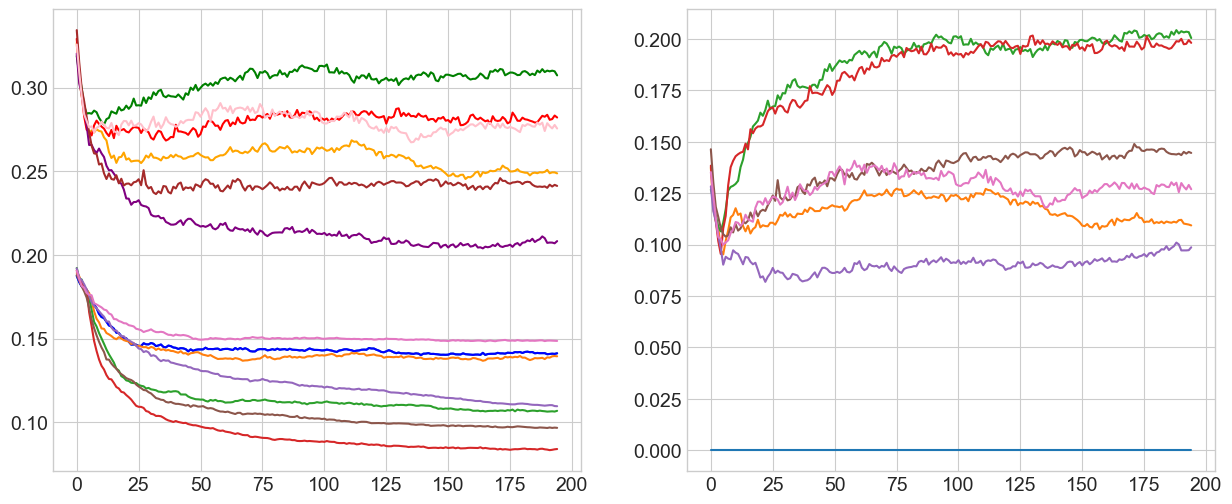

In [90]:
plt.figure(figsize=(15,6))
for mo in interactions.keys():
    plt.subplot(1, 2, 1)
    values = gaussian_filter1d((inter_RMSD_minus_one[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    values = gaussian_filter1d((ideal_inter_RMSD_minus_one[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo][4:])
    plt.subplot(1, 2, 2)
    values = gaussian_filter1d((ideal_inter_RMSD_minus_one[mo] - inter_RMSD_minus_one[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
plt.show()

### MSD

In [102]:
inter_MSD = dict()
ideal_inter_MSD = dict()
for mo in interactions.keys():
    inter_MSD[mo] = []
    ideal_inter_MSD[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        re2 = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_attrs_ideal = item_attrs[i].T[interactions['ideal'][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            ideal_mean_user_attrs = user_iter_attrs_ideal[:,:(j+1)].mean(axis=1)
            diffs = []
            nearest_users = get_sim_users_pairs(mean_user_attrs)
            pair_distance = 0
            ideal_pair_distance = 0
            for p in nearest_users:
                mean_pair_point = (mean_user_attrs[p[0]] + mean_user_attrs[p[1]]) / len(p)
                ideal_mean_pair_point = (ideal_mean_user_attrs[p[0]] + ideal_mean_user_attrs[p[1]]) / len(p)
                pair_distance += np.linalg.norm(mean_user_attrs[p[0]] - mean_pair_point)**2
                ideal_pair_distance += np.linalg.norm(ideal_mean_user_attrs[p[0]] - ideal_mean_pair_point)**2
            re.append(pair_distance / len(nearest_users))
            re2.append(ideal_pair_distance / len(nearest_users))
        inter_MSD[mo].append(re)
        ideal_inter_MSD[mo].append(re2)
    inter_MSD[mo] = np.array(inter_MSD[mo])
    ideal_inter_MSD[mo] = np.array(ideal_inter_MSD[mo])

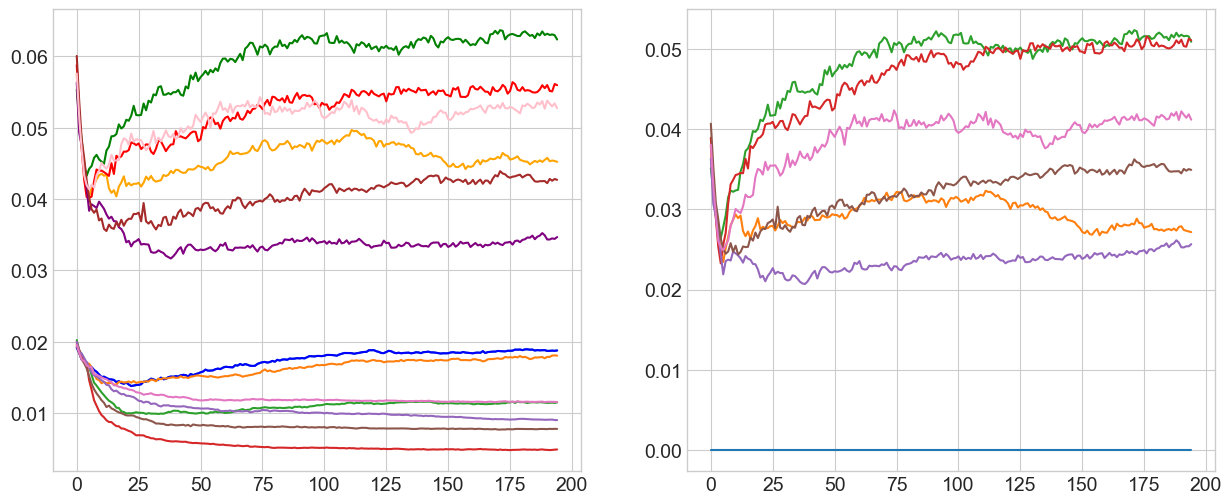

In [103]:
plt.figure(figsize=(15,6))
for mo in interactions.keys():
    plt.subplot(1, 2, 1)
    values = gaussian_filter1d((inter_MSD[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    values = gaussian_filter1d((ideal_inter_MSD[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo][4:])
    plt.subplot(1, 2, 2)
    values = gaussian_filter1d((ideal_inter_MSD[mo] - inter_MSD[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
plt.show()

In [94]:
inter_WMSD = dict()
ideal_inter_WMSD = dict()
for mo in interactions.keys():
    inter_WMSD[mo] = []
    ideal_inter_WMSD[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        re2 = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_attrs_ideal = item_attrs[i].T[interactions['ideal'][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            ideal_mean_user_attrs = user_iter_attrs_ideal[:,:(j+1)].mean(axis=1)
            diffs = []
            nearest_users = get_sim_users_pairs(mean_user_attrs)
            pair_distance = 0
            ideal_pair_distance = 0
            for p in nearest_users:
                mean_pair_point = (mean_user_attrs[p[0]] + mean_user_attrs[p[1]]) / len(p)
                ideal_mean_pair_point = (ideal_mean_user_attrs[p[0]] + ideal_mean_user_attrs[p[1]]) / len(p)
                pair_distance += (j+1)*np.linalg.norm(mean_user_attrs[p[0]] - mean_pair_point)**2
                ideal_pair_distance += (j+1)*np.linalg.norm(ideal_mean_user_attrs[p[0]] - ideal_mean_pair_point)**2
            re.append(pair_distance / len(nearest_users))
            re2.append(ideal_pair_distance / len(nearest_users))
        inter_WMSD[mo].append(re)
        ideal_inter_WMSD[mo].append(re2)
    inter_WMSD[mo] = np.array(inter_WMSD[mo])
    ideal_inter_WMSD[mo] = np.array(ideal_inter_WMSD[mo])

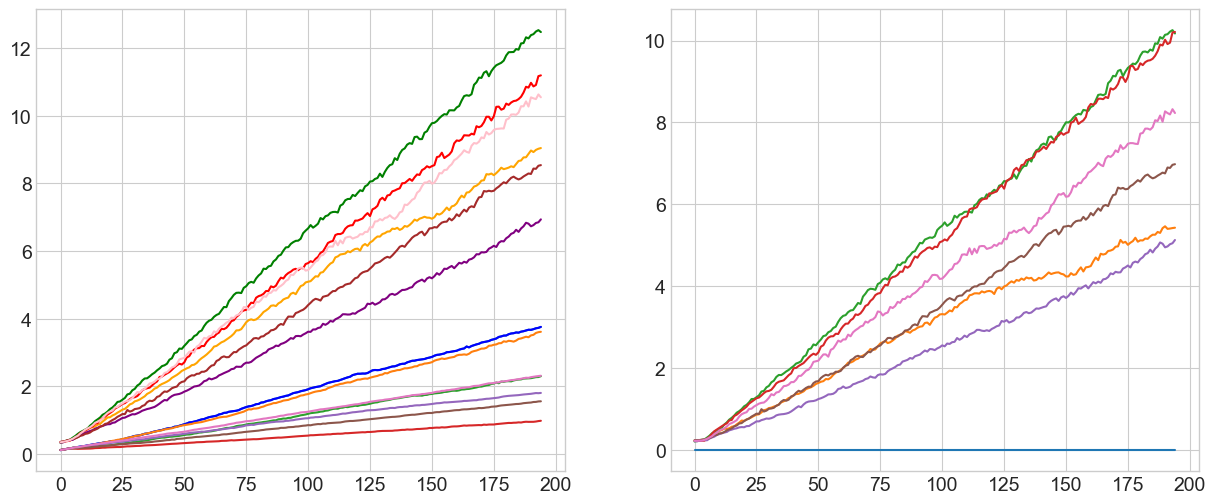

In [99]:
plt.figure(figsize=(15,6))
for mo in interactions.keys():
    plt.subplot(1, 2, 1)
    values = gaussian_filter1d((inter_WMSD[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    values = gaussian_filter1d((ideal_inter_WMSD[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo][4:])
    plt.subplot(1, 2, 2)
    values = gaussian_filter1d((ideal_inter_WMSD[mo] - inter_WMSD[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
plt.show()

In [95]:
inter_WMSD_minus_one = dict()
ideal_inter_WMSD_minus_one = dict()
for mo in interactions.keys():
    inter_WMSD_minus_one[mo] = []
    ideal_inter_WMSD_minus_one[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        re2 = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_attrs_ideal = item_attrs[i].T[interactions['ideal'][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            ideal_mean_user_attrs = user_iter_attrs_ideal[:,:(j+1)].mean(axis=1)
            diffs = []
            nearest_users = get_sim_users_pairs(mean_user_attrs)
            pair_distance = 0
            ideal_pair_distance = 0
            for p in nearest_users:
                mean_pair_point = (mean_user_attrs[p[0]] + mean_user_attrs[p[1]]) / len(p)
                ideal_mean_pair_point = (ideal_mean_user_attrs[p[0]] + ideal_mean_user_attrs[p[1]]) / len(p)
                pair_distance += 2*(j+1)*np.linalg.norm(mean_user_attrs[p[0]] - mean_pair_point)**2
                ideal_pair_distance += 2*(j+1)*np.linalg.norm(ideal_mean_user_attrs[p[0]] - ideal_mean_pair_point)**2
            re.append(pair_distance / len(nearest_users))
            re2.append(ideal_pair_distance / len(nearest_users))
        inter_WMSD_minus_one[mo].append(re)
        ideal_inter_WMSD_minus_one[mo].append(re2)
    inter_WMSD_minus_one[mo] = np.array(inter_WMSD_minus_one[mo])
    ideal_inter_WMSD_minus_one[mo] = np.array(ideal_inter_WMSD_minus_one[mo])

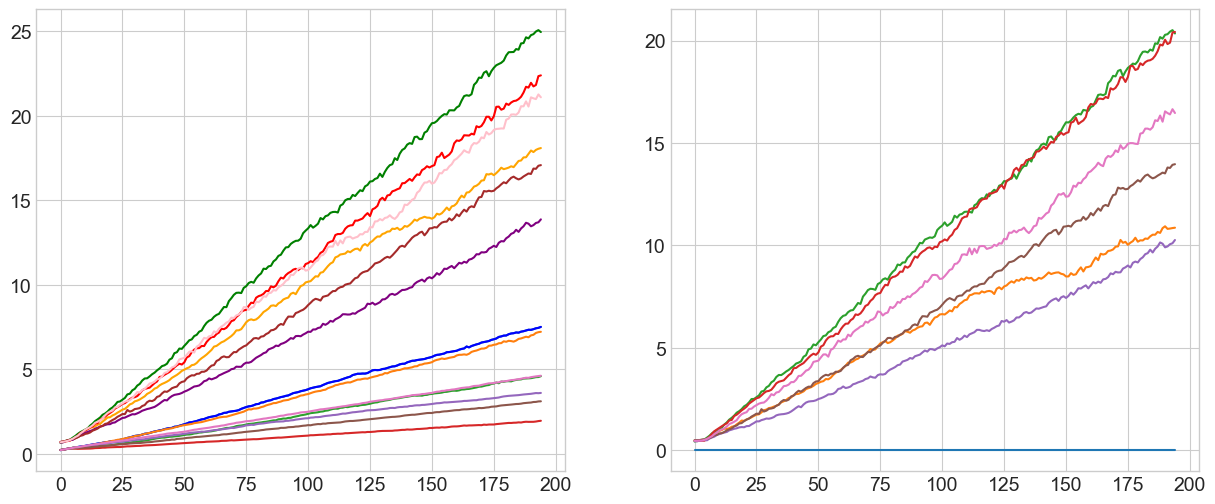

In [96]:
plt.figure(figsize=(15,6))
for mo in interactions.keys():
    plt.subplot(1, 2, 1)
    values = gaussian_filter1d((inter_WMSD_minus_one[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    values = gaussian_filter1d((ideal_inter_WMSD_minus_one[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo][4:])
    plt.subplot(1, 2, 2)
    values = gaussian_filter1d((ideal_inter_WMSD_minus_one[mo] - inter_WMSD_minus_one[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
plt.show()

In [97]:
inter_MSD_minus_one = dict()
ideal_inter_MSD_minus_one = dict()
for mo in interactions.keys():
    inter_MSD_minus_one[mo] = []
    ideal_inter_MSD_minus_one[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        re2 = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_attrs_ideal = item_attrs[i].T[interactions['ideal'][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            ideal_mean_user_attrs = user_iter_attrs_ideal[:,:(j+1)].mean(axis=1)
            diffs = []
            nearest_users = get_sim_users_pairs(mean_user_attrs)
            pair_distance = 0
            ideal_pair_distance = 0
            for p in nearest_users:
                mean_pair_point = (mean_user_attrs[p[0]] + mean_user_attrs[p[1]]) / len(p)
                ideal_mean_pair_point = (ideal_mean_user_attrs[p[0]] + ideal_mean_user_attrs[p[1]]) / len(p)
                pair_distance += 2*np.linalg.norm(mean_user_attrs[p[0]] - mean_pair_point)**2
                ideal_pair_distance += 2*np.linalg.norm(ideal_mean_user_attrs[p[0]] - ideal_mean_pair_point)**2
            re.append(pair_distance / len(nearest_users))
            re2.append(ideal_pair_distance / len(nearest_users))
        inter_MSD_minus_one[mo].append(re)
        ideal_inter_MSD_minus_one[mo].append(re2)
    inter_MSD_minus_one[mo] = np.array(inter_MSD_minus_one[mo])
    ideal_inter_MSD_minus_one[mo] = np.array(ideal_inter_MSD_minus_one[mo])

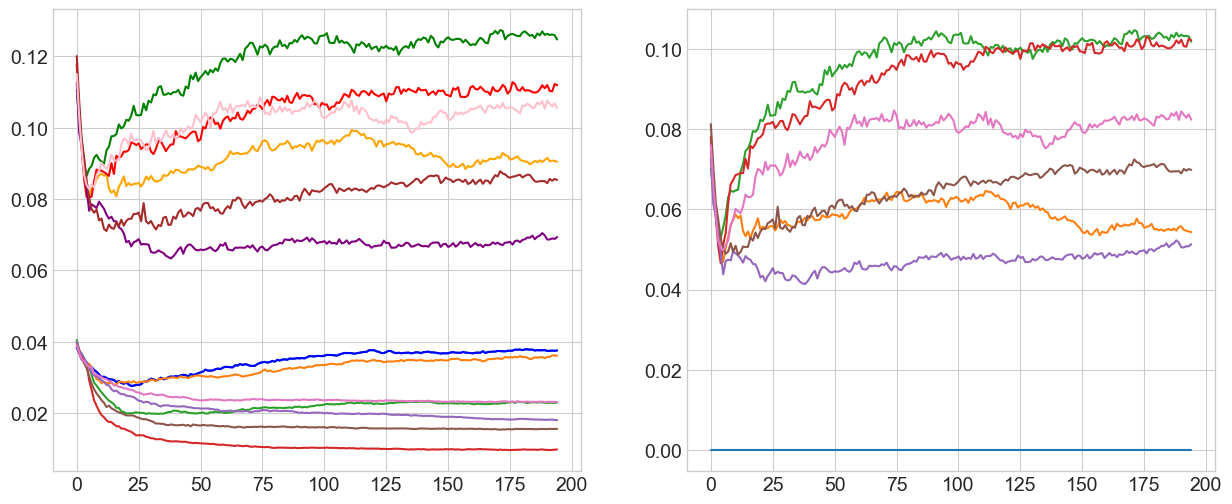

In [98]:
plt.figure(figsize=(15,6))
for mo in interactions.keys():
    plt.subplot(1, 2, 1)
    values = gaussian_filter1d((inter_MSD_minus_one[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    values = gaussian_filter1d((ideal_inter_MSD_minus_one[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo][4:])
    plt.subplot(1, 2, 2)
    values = gaussian_filter1d((ideal_inter_MSD_minus_one[mo] - inter_MSD_minus_one[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
plt.show()

## Intra-User Diversity

In [36]:
intra_MRMSD = dict()
ideal_intra_MRMSD = dict()
for mo in interactions.keys():
    intra_MRMSD[mo] = []
    ideal_intra_MRMSD[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        re2 = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_attrs_ideal = item_attrs[i].T[interactions['ideal'][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            ideal_mean_user_attrs = user_iter_attrs_ideal[:,:(j+1)].mean(axis=1)
            nearest_users = get_sim_users_pairs(mean_user_attrs)
            pair_variance = 0
            ideal_pair_variance = 0
            for p in nearest_users:
                distances_0 = np.linalg.norm(user_iter_attrs[p[0],:(j+1)] - mean_user_attrs[p[0]], axis=1)
                distances_1 = np.linalg.norm(user_iter_attrs[p[1],:(j+1)] - mean_user_attrs[p[1]], axis=1)
                variance_0 = ((distances_0**2).sum())/distances_0.shape[0]
                variance_1 = ((distances_1**2).sum())/distances_1.shape[0]
                pair_variance += ((variance_0**0.5 + variance_1**0.5) / 2) / len(nearest_users)

                distances_0 = np.linalg.norm(user_iter_attrs_ideal[p[0],:(j+1)] - ideal_mean_user_attrs[p[0]], axis=1)
                distances_1 = np.linalg.norm(user_iter_attrs_ideal[p[1],:(j+1)] - ideal_mean_user_attrs[p[1]], axis=1)
                variance_0 = ((distances_0**2).sum())/distances_0.shape[0]
                variance_1 = ((distances_1**2).sum())/distances_1.shape[0]
                ideal_pair_variance += ((variance_0**0.5 + variance_1**0.5) / 2) / len(nearest_users)
            re.append(pair_variance)
            re2.append(ideal_pair_variance)
        intra_MRMSD[mo].append(re)
        ideal_intra_MRMSD[mo].append(re2)
    intra_MRMSD[mo] = np.array(intra_MRMSD[mo])
    ideal_intra_MRMSD[mo] = np.array(ideal_intra_MRMSD[mo])

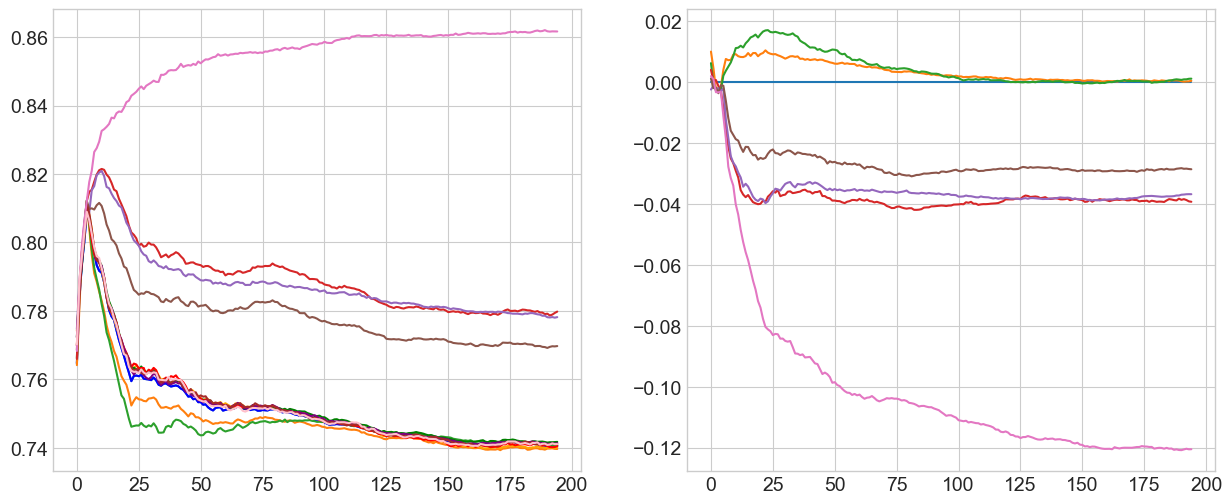

In [37]:
plt.figure(figsize=(15,6))
for mo in interactions.keys():
    plt.subplot(1, 2, 1)
    values = gaussian_filter1d((intra_MRMSD[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    values = gaussian_filter1d((ideal_intra_MRMSD[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo][4:])
    plt.subplot(1, 2, 2)
    values = gaussian_filter1d((ideal_intra_MRMSD[mo] - intra_MRMSD[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
plt.show()

In [105]:
intra_MRMSD_minus_one = dict()
ideal_intra_MRMSD_minus_one = dict()
for mo in interactions.keys():
    intra_MRMSD_minus_one[mo] = []
    ideal_intra_MRMSD_minus_one[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        re2 = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_attrs_ideal = item_attrs[i].T[interactions['ideal'][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            ideal_mean_user_attrs = user_iter_attrs_ideal[:,:(j+1)].mean(axis=1)
            nearest_users = get_sim_users_pairs(mean_user_attrs)
            pair_variance = 0
            ideal_pair_variance = 0
            for p in nearest_users:
                distances_0 = np.linalg.norm(user_iter_attrs[p[0],:(j+1)] - mean_user_attrs[p[0]], axis=1)
                distances_1 = np.linalg.norm(user_iter_attrs[p[1],:(j+1)] - mean_user_attrs[p[1]], axis=1)
                variance_0 = ((distances_0**2).sum())/(distances_0.shape[0] - 1) if j > 0 else 0
                variance_1 = ((distances_1**2).sum())/(distances_1.shape[0] - 1) if j > 0 else 0
                pair_variance += ((variance_0**0.5 + variance_1**0.5) / 2) / len(nearest_users)

                distances_0 = np.linalg.norm(user_iter_attrs_ideal[p[0],:(j+1)] - ideal_mean_user_attrs[p[0]], axis=1)
                distances_1 = np.linalg.norm(user_iter_attrs_ideal[p[1],:(j+1)] - ideal_mean_user_attrs[p[1]], axis=1)
                variance_0 = ((distances_0**2).sum())/(distances_0.shape[0] - 1) if j > 0 else 0
                variance_1 = ((distances_1**2).sum())/(distances_1.shape[0] - 1) if j > 0 else 0
                ideal_pair_variance += ((variance_0**0.5 + variance_1**0.5) / 2) / len(nearest_users)
            re.append(pair_variance)
            re2.append(ideal_pair_variance)
        intra_MRMSD_minus_one[mo].append(re)
        ideal_intra_MRMSD_minus_one[mo].append(re2)
    intra_MRMSD_minus_one[mo] = np.array(intra_MRMSD_minus_one[mo])
    ideal_intra_MRMSD_minus_one[mo] = np.array(ideal_intra_MRMSD_minus_one[mo])

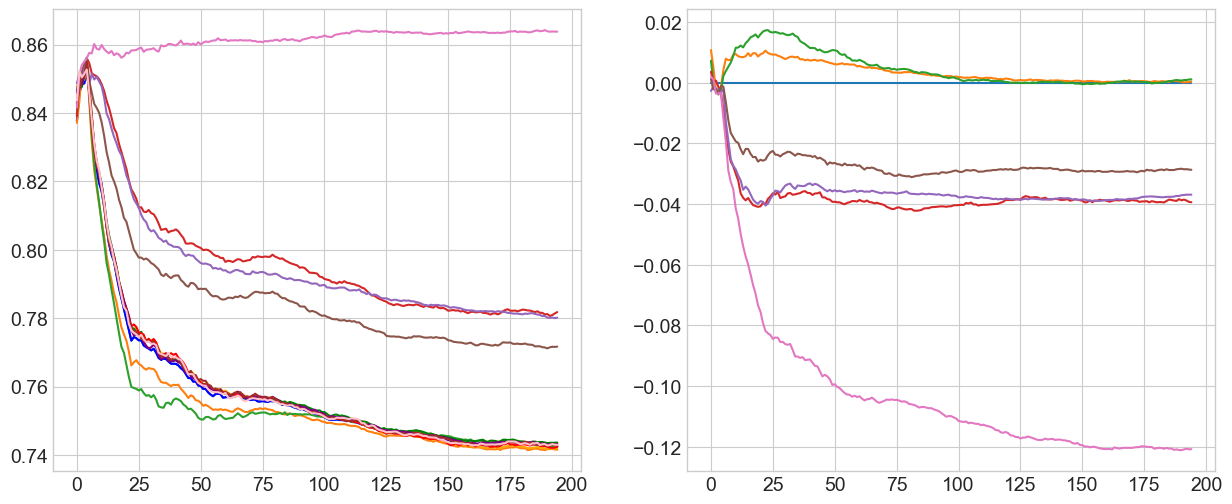

In [106]:
plt.figure(figsize=(15,6))
for mo in interactions.keys():
    plt.subplot(1, 2, 1)
    values = gaussian_filter1d((intra_MRMSD_minus_one[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    values = gaussian_filter1d((ideal_intra_MRMSD_minus_one[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo][4:])
    plt.subplot(1, 2, 2)
    values = gaussian_filter1d((ideal_intra_MRMSD_minus_one[mo] - intra_MRMSD_minus_one[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
plt.show()

In [107]:
intra_MMSD_minus_one = dict()
ideal_intra_MMSD_minus_one = dict()
for mo in interactions.keys():
    intra_MMSD_minus_one[mo] = []
    ideal_intra_MMSD_minus_one[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        re2 = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_attrs_ideal = item_attrs[i].T[interactions['ideal'][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            ideal_mean_user_attrs = user_iter_attrs_ideal[:,:(j+1)].mean(axis=1)
            nearest_users = get_sim_users_pairs(mean_user_attrs)
            pair_variance = 0
            ideal_pair_variance = 0
            for p in nearest_users:
                distances_0 = np.linalg.norm(user_iter_attrs[p[0],:(j+1)] - mean_user_attrs[p[0]], axis=1)
                distances_1 = np.linalg.norm(user_iter_attrs[p[1],:(j+1)] - mean_user_attrs[p[1]], axis=1)
                variance_0 = ((distances_0**2).sum())/(distances_0.shape[0] - 1) if j > 0 else 0
                variance_1 = ((distances_1**2).sum())/(distances_1.shape[0] - 1) if j > 0 else 0
                pair_variance += ((variance_0 + variance_1) / 2) / len(nearest_users)

                distances_0 = np.linalg.norm(user_iter_attrs_ideal[p[0],:(j+1)] - ideal_mean_user_attrs[p[0]], axis=1)
                distances_1 = np.linalg.norm(user_iter_attrs_ideal[p[1],:(j+1)] - ideal_mean_user_attrs[p[1]], axis=1)
                variance_0 = ((distances_0**2).sum())/(distances_0.shape[0] - 1) if j > 0 else 0
                variance_1 = ((distances_1**2).sum())/(distances_1.shape[0] - 1) if j > 0 else 0
                ideal_pair_variance += ((variance_0 + variance_1) / 2) / len(nearest_users)
            re.append(pair_variance)
            re2.append(ideal_pair_variance)
        intra_MMSD_minus_one[mo].append(re)
        ideal_intra_MMSD_minus_one[mo].append(re2)
    intra_MMSD_minus_one[mo] = np.array(intra_MMSD_minus_one[mo])
    ideal_intra_MMSD_minus_one[mo] = np.array(ideal_intra_MMSD_minus_one[mo])

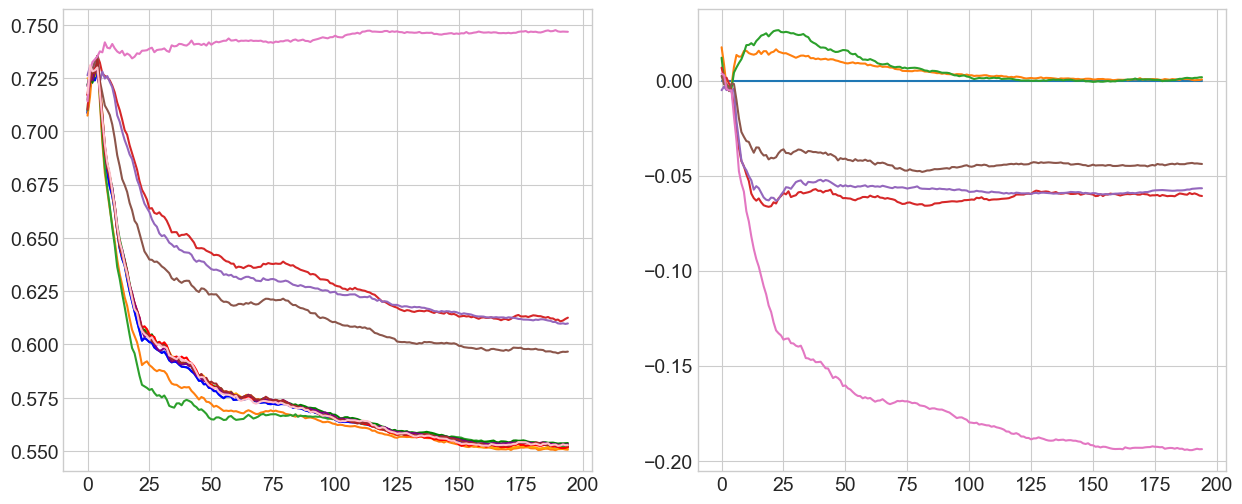

In [108]:
plt.figure(figsize=(15,6))
for mo in interactions.keys():
    plt.subplot(1, 2, 1)
    values = gaussian_filter1d((intra_MMSD_minus_one[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    values = gaussian_filter1d((ideal_intra_MMSD_minus_one[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo][4:])
    plt.subplot(1, 2, 2)
    values = gaussian_filter1d((ideal_intra_MMSD_minus_one[mo] - intra_MMSD_minus_one[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
plt.show()

In [109]:
intra_WCSS_normalized = dict()
ideal_intra_WCSS_normalized = dict()
for mo in interactions.keys():
    intra_WCSS_normalized[mo] = []
    ideal_intra_WCSS_normalized[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        re2 = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_attrs_ideal = item_attrs[i].T[interactions['ideal'][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            ideal_mean_user_attrs = user_iter_attrs_ideal[:,:(j+1)].mean(axis=1)
            nearest_users = get_sim_users_pairs(mean_user_attrs)
            pair_variance = 0
            ideal_pair_variance = 0
            for p in nearest_users:
                distances_0 = np.linalg.norm(user_iter_attrs[p[0],:(j+1)] - mean_user_attrs[p[0]], axis=1)
                distances_1 = np.linalg.norm(user_iter_attrs[p[1],:(j+1)] - mean_user_attrs[p[1]], axis=1)
                variance_0 = ((distances_0**2).sum())/(j+1-len(p)) if j+1-len(p) > 0 else 0
                variance_1 = ((distances_1**2).sum())/(j+1-len(p)) if j+1-len(p) > 0 else 0
                pair_variance += ((variance_0 + variance_1) / 2) / len(nearest_users)

                distances_0 = np.linalg.norm(user_iter_attrs_ideal[p[0],:(j+1)] - ideal_mean_user_attrs[p[0]], axis=1)
                distances_1 = np.linalg.norm(user_iter_attrs_ideal[p[1],:(j+1)] - ideal_mean_user_attrs[p[1]], axis=1)
                variance_0 = ((distances_0**2).sum())/(j+1-len(p)) if j+1-len(p) > 0 else 0
                variance_1 = ((distances_1**2).sum())/(j+1-len(p)) if j+1-len(p) > 0 else 0
                ideal_pair_variance += ((variance_0 + variance_1) / 2) / len(nearest_users)
            re.append(pair_variance)
            re2.append(ideal_pair_variance)
        intra_WCSS_normalized[mo].append(re)
        ideal_intra_WCSS_normalized[mo].append(re2)
    intra_WCSS_normalized[mo] = np.array(intra_WCSS_normalized[mo])
    ideal_intra_WCSS_normalized[mo] = np.array(ideal_intra_WCSS_normalized[mo])

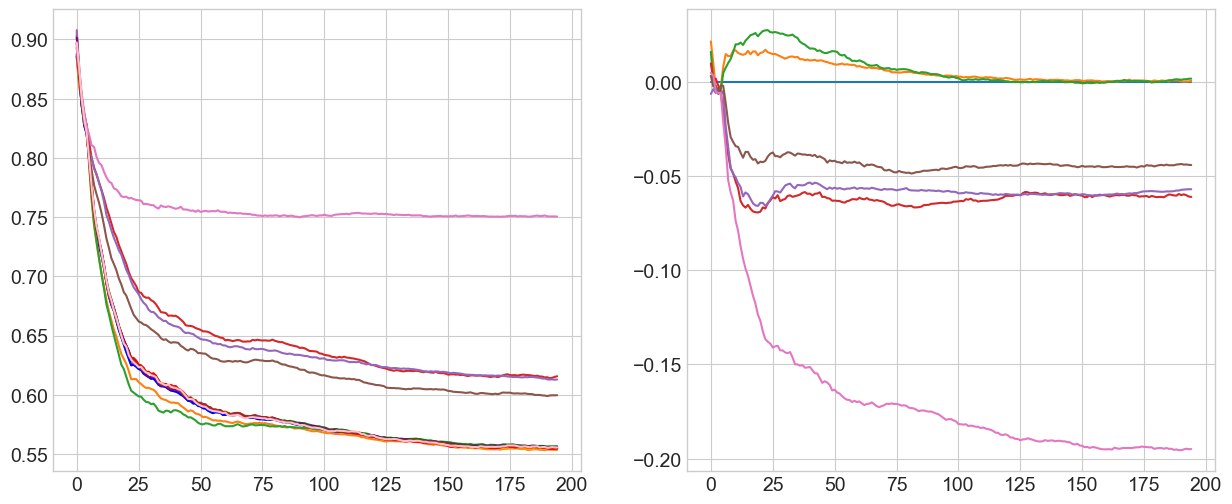

In [110]:
plt.figure(figsize=(15,6))
for mo in interactions.keys():
    plt.subplot(1, 2, 1)
    values = gaussian_filter1d((intra_WCSS_normalized[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    values = gaussian_filter1d((ideal_intra_WCSS_normalized[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo][4:])
    plt.subplot(1, 2, 2)
    values = gaussian_filter1d((ideal_intra_WCSS_normalized[mo] - intra_WCSS_normalized[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
plt.show()

In [111]:
intra_NRMSD = dict()
ideal_intra_NRMSD = dict()
for mo in interactions.keys():
    intra_NRMSD[mo] = []
    ideal_intra_NRMSD[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        re2 = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_attrs_ideal = item_attrs[i].T[interactions['ideal'][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            ideal_mean_user_attrs = user_iter_attrs_ideal[:,:(j+1)].mean(axis=1)
            nearest_users = get_sim_users_pairs(mean_user_attrs)
            pair_variance = 0
            ideal_pair_variance = 0
            for p in nearest_users:
                distances_0 = np.linalg.norm(user_iter_attrs[p[0],:(j+1)] - mean_user_attrs[p[0]], axis=1)
                distances_1 = np.linalg.norm(user_iter_attrs[p[1],:(j+1)] - mean_user_attrs[p[1]], axis=1)
                variance_0 = ((distances_0**2).sum())/distances_0.shape[0]
                variance_1 = ((distances_1**2).sum())/distances_1.shape[0]
                pair_variance += (variance_0**0.5 + variance_1**0.5) / len(nearest_users)

                distances_0 = np.linalg.norm(user_iter_attrs_ideal[p[0],:(j+1)] - ideal_mean_user_attrs[p[0]], axis=1)
                distances_1 = np.linalg.norm(user_iter_attrs_ideal[p[1],:(j+1)] - ideal_mean_user_attrs[p[1]], axis=1)
                variance_0 = ((distances_0**2).sum())/distances_0.shape[0]
                variance_1 = ((distances_1**2).sum())/distances_1.shape[0]
                ideal_pair_variance += (variance_0**0.5 + variance_1**0.5) / len(nearest_users)
            re.append(pair_variance)
            re2.append(ideal_pair_variance)
        intra_NRMSD[mo].append(re)
        ideal_intra_NRMSD[mo].append(re2)
    intra_NRMSD[mo] = np.array(intra_NRMSD[mo])
    ideal_intra_NRMSD[mo] = np.array(ideal_intra_NRMSD[mo])

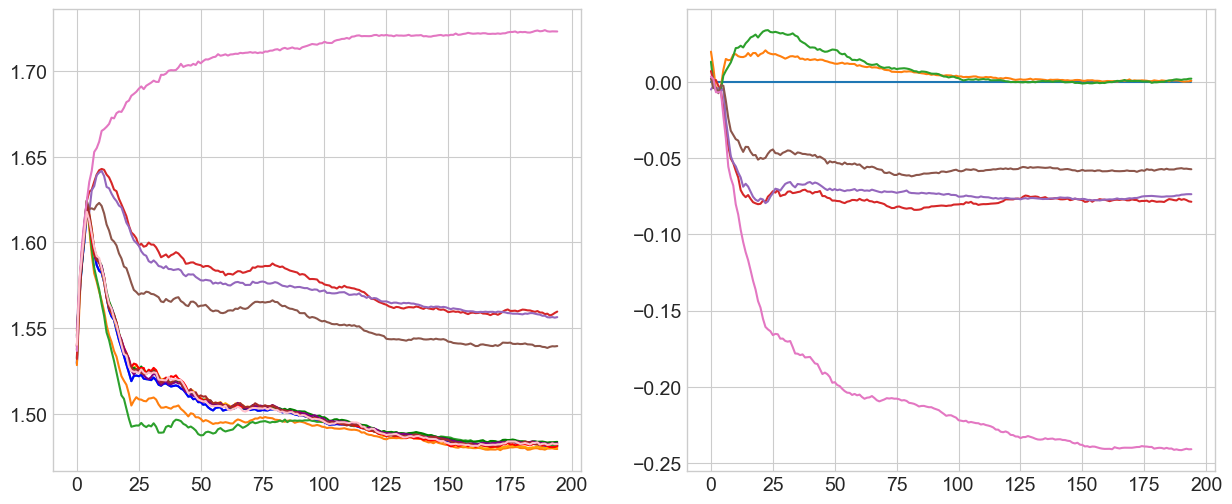

In [112]:
plt.figure(figsize=(15,6))
for mo in interactions.keys():
    plt.subplot(1, 2, 1)
    values = gaussian_filter1d((intra_NRMSD[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    values = gaussian_filter1d((ideal_intra_NRMSD[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo][4:])
    plt.subplot(1, 2, 2)
    values = gaussian_filter1d((ideal_intra_NRMSD[mo] - intra_NRMSD[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
plt.show()

## Other stuff

### MRMSD de centroide general

In [137]:
intra_MRMSD_central = dict()
ideal_intra_MRMSD_central = dict()
for mo in interactions.keys():
    intra_MRMSD_central[mo] = []
    ideal_intra_MRMSD_central[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        re2 = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_attrs_ideal = item_attrs[i].T[interactions['ideal'][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            ideal_mean_user_attrs = user_iter_attrs_ideal[:,:(j+1)].mean(axis=1)
            nearest_users = get_sim_users_pairs(mean_user_attrs)
            pair_variance = 0
            ideal_pair_variance = 0
            for p in nearest_users:
                mean_pair_point = (mean_user_attrs[p[0]] + mean_user_attrs[p[1]]) / len(p)
                distances_0 = np.linalg.norm(user_iter_attrs[p[0],:(j+1)] - mean_pair_point, axis=1)
                distances_1 = np.linalg.norm(user_iter_attrs[p[1],:(j+1)] - mean_pair_point, axis=1)
                variance_0 = ((distances_0**2).sum())/distances_0.shape[0]
                variance_1 = ((distances_1**2).sum())/distances_1.shape[0]
                pair_variance += ((variance_0**0.5 + variance_1**0.5) / 2) / len(nearest_users)

                ideal_mean_pair_point = (ideal_mean_user_attrs[p[0]] + ideal_mean_user_attrs[p[1]]) / len(p)
                distances_0 = np.linalg.norm(user_iter_attrs_ideal[p[0],:(j+1)] - ideal_mean_pair_point, axis=1)
                distances_1 = np.linalg.norm(user_iter_attrs_ideal[p[1],:(j+1)] - ideal_mean_pair_point, axis=1)
                variance_0 = ((distances_0**2).sum())/distances_0.shape[0]
                variance_1 = ((distances_1**2).sum())/distances_1.shape[0]
                ideal_pair_variance += ((variance_0**0.5 + variance_1**0.5) / 2) / len(nearest_users)
            re.append(pair_variance)
            re2.append(ideal_pair_variance)
        intra_MRMSD_central[mo].append(re)
        ideal_intra_MRMSD_central[mo].append(re2)
    intra_MRMSD_central[mo] = np.array(intra_MRMSD_central[mo])
    ideal_intra_MRMSD_central[mo] = np.array(ideal_intra_MRMSD_central[mo])

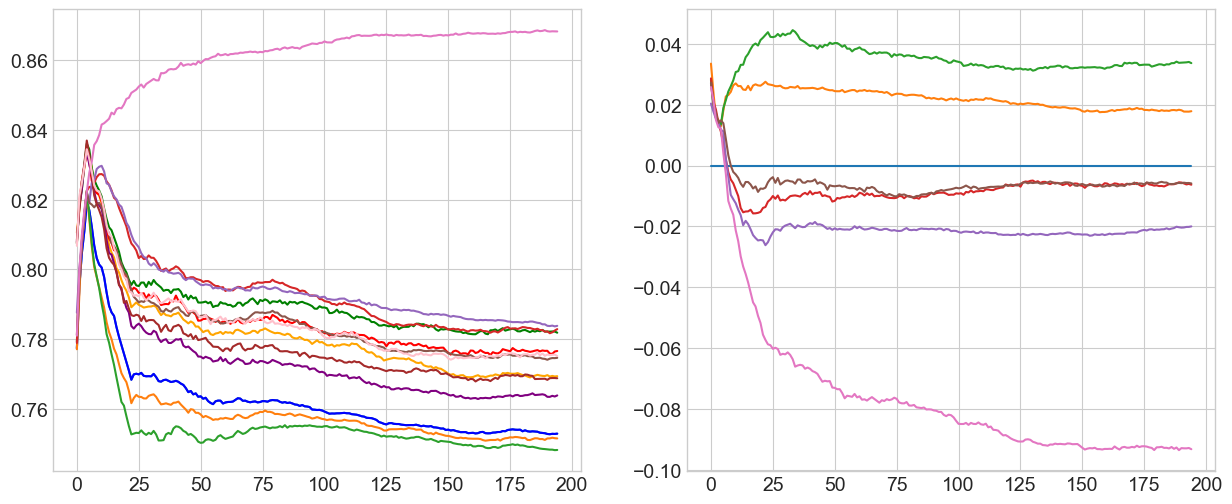

In [138]:
plt.figure(figsize=(15,6))
for mo in interactions.keys():
    plt.subplot(1, 2, 1)
    values = gaussian_filter1d((intra_MRMSD_central[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    values = gaussian_filter1d((ideal_intra_MRMSD_central[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo][4:])
    plt.subplot(1, 2, 2)
    values = gaussian_filter1d((ideal_intra_MRMSD_central[mo] - intra_MRMSD_central[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
plt.show()

### Overlap index?

In [78]:
overlap_index = dict()
ideal_overlap_index = dict()
for mo in interactions.keys():
    overlap_index[mo] = []
    ideal_overlap_index[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        re2 = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_indices = interactions[mo][i]
        user_iter_indices_ideal = interactions['ideal'][i]
        for j in range(user_iter_indices.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            user_jiter_indices = user_iter_indices[:,:(j+1)]
            user_jiter_indices_ideal = user_iter_indices_ideal[:,:(j+1)]
            nearest_users = get_sim_users_pairs(mean_user_attrs)
            total_interactions = 2*(j+1)
            overlap = 0
            ideal_overlap = 0
            for p in nearest_users:
                interacted_items = (np.bincount(np.append(user_jiter_indices[p[0]], user_jiter_indices[p[1]])) > 0).sum()
                overlap += ((total_interactions - interacted_items) / interacted_items) / len(nearest_users)

                interacted_items = (np.bincount(np.append(user_jiter_indices_ideal[p[0]], user_jiter_indices_ideal[p[1]])) > 0).sum()
                ideal_overlap += ((total_interactions - interacted_items) / interacted_items) / len(nearest_users)
            re.append(overlap)
            re2.append(ideal_overlap)
        overlap_index[mo].append(re)
        ideal_overlap_index[mo].append(re2)
    overlap_index[mo] = np.array(overlap_index[mo])
    ideal_overlap_index[mo] = np.array(ideal_overlap_index[mo])

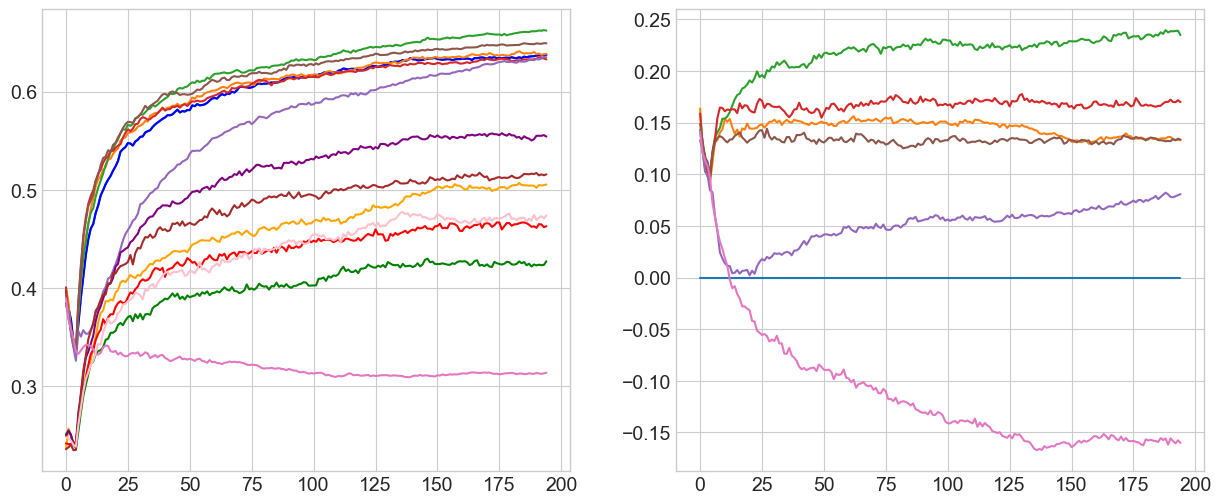

In [79]:
plt.figure(figsize=(15,6))
for mo in interactions.keys():
    plt.subplot(1, 2, 1)
    values = gaussian_filter1d((overlap_index[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    values = gaussian_filter1d((ideal_overlap_index[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo][4:])
    plt.subplot(1, 2, 2)
    values = gaussian_filter1d((-ideal_overlap_index[mo] + overlap_index[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
plt.show()

### Disimilaridad de Qamar, U (2014)

In [230]:
dissim_index = dict()
ideal_dissim_index = dict()
for mo in interactions.keys():
    dissim_index[mo] = []
    ideal_dissim_index[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        re2 = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_attrs_ideal = item_attrs[i].T[interactions['ideal'][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            ideal_mean_user_attrs = user_iter_attrs_ideal[:,:(j+1)].mean(axis=1)
            nearest_users = get_sim_users_pairs(mean_user_attrs)
            dissim = 0
            ideal_dissim = 0
            for p in nearest_users:
                dissim_01 = (abs(user_iter_attrs[p[0],:(j+1)] - mean_user_attrs[p[1]])).sum()
                dissim_10 = (abs(user_iter_attrs[p[1],:(j+1)] - mean_user_attrs[p[0]])).sum()
                dissim += (dissim_01 + dissim_10) / (2*(j+1)*len(nearest_users))

                ideal_dissim_01 = (abs(user_iter_attrs_ideal[p[0],:(j+1)] - ideal_mean_user_attrs[p[1]])).sum()
                ideal_dissim_10 = (abs(user_iter_attrs_ideal[p[1],:(j+1)] - ideal_mean_user_attrs[p[0]])).sum()
                ideal_dissim += (ideal_dissim_01 + ideal_dissim_10) / (2*(j+1)*len(nearest_users))
            re.append(dissim)
            re2.append(ideal_dissim)
        dissim_index[mo].append(re)
        ideal_dissim_index[mo].append(re2)
    dissim_index[mo] = np.array(dissim_index[mo])
    ideal_dissim_index[mo] = np.array(ideal_dissim_index[mo])

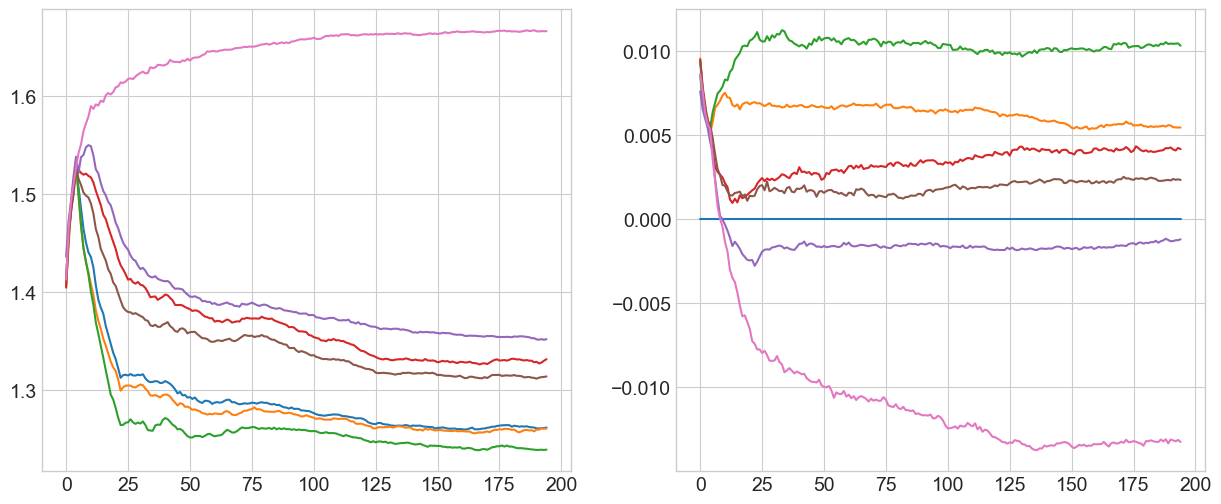

In [231]:
plt.figure(figsize=(15,6))
for mo in interactions.keys():
    plt.subplot(1, 2, 1)
    values = gaussian_filter1d((dissim_index[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    values = gaussian_filter1d((ideal_dissim_index[mo]).mean(axis=0), sigma=0.1)
    #plt.plot(values[5:], color=colors[mo][4:])
    plt.subplot(1, 2, 2)
    values = gaussian_filter1d(((ideal_dissim_index[mo] - dissim_index[mo])/20).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
plt.show()

In [194]:
%%script false
maha_dist = dict()
ideal_maha_dist = dict()
for mo in interactions.keys():
    maha_dist[mo] = []
    ideal_maha_dist[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        re2 = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_attrs_ideal = item_attrs[i].T[interactions['ideal'][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            ideal_mean_user_attrs = user_iter_attrs_ideal[:,:(j+1)].mean(axis=1)
            nearest_users = get_sim_users_pairs(mean_user_attrs)
            maha = 0
            ideal_maha = 0
            for p in nearest_users:
                if j < 21:
                    distances_0 = np.linalg.norm(user_iter_attrs[p[0],:(j+1)] - mean_user_attrs[p[1]], axis=1)
                    distances_1 = np.linalg.norm(user_iter_attrs[p[1],:(j+1)] - mean_user_attrs[p[0]], axis=1)
                    maha += (distances_0.sum() + distances_1.sum()) / (2*(j+1))

                    distances_0 = np.linalg.norm(user_iter_attrs_ideal[p[0],:(j+1)] - ideal_mean_user_attrs[p[1]], axis=1)
                    distances_1 = np.linalg.norm(user_iter_attrs_ideal[p[1],:(j+1)] - ideal_mean_user_attrs[p[0]], axis=1)
                    ideal_maha += (distances_0.sum() + distances_1.sum()) / (2*(j+1))

                else:
                    s_0 = np.linalg.inv(np.cov(user_iter_attrs[p[0],:(j+1)], rowvar=False))
                    s_1 = np.linalg.inv(np.cov(user_iter_attrs[p[1],:(j+1)], rowvar=False))
                    diff_0 = user_iter_attrs[p[0],:(j+1)] - mean_user_attrs[p[1]]
                    diff_1 = user_iter_attrs[p[1],:(j+1)] - mean_user_attrs[p[0]]
                    distances_0 = ((diff_0@s_1)*diff_0).sum(axis=1)
                    distances_1 = ((diff_1@s_0)*diff_1).sum(axis=1)
                    maha += ((distances_0**0.5).sum() + (distances_1**0.5).sum()) / (2*(j+1))

                    s_0 = np.linalg.inv(np.cov(user_iter_attrs_ideal[p[0],:(j+1)], rowvar=False))
                    s_1 = np.linalg.inv(np.cov(user_iter_attrs_ideal[p[1],:(j+1)], rowvar=False))
                    diff_0 = user_iter_attrs_ideal[p[0],:(j+1)] - ideal_mean_user_attrs[p[1]]
                    diff_1 = user_iter_attrs_ideal[p[1],:(j+1)] - ideal_mean_user_attrs[p[0]]
                    distances_0 = ((diff_0@s_1)*diff_0).sum(axis=1)
                    distances_1 = ((diff_1@s_0)*diff_1).sum(axis=1)
                    ideal_maha += ((distances_0**0.5).sum() + (distances_1**0.5).sum()) / (2*(j+1))
                
            re.append(maha)
            re2.append(ideal_maha)
        maha_dist[mo].append(re)
        ideal_maha_dist[mo].append(re2)
    maha_dist[mo] = np.array(maha_dist[mo])
    ideal_maha_dist[mo] = np.array(ideal_maha_dist[mo])

Couldn't find program: 'false'


### Earth Mover's Distance (testing)

In [22]:
def compute_distance_matrix(set_A, set_B):
    d = set_A[:,np.newaxis,:] - set_B[np.newaxis,:,:]
    d = np.linalg.norm(d, axis=2)
    return d

In [23]:
def compute_flow_matrix(set_A, set_B, distance_matrix):
    distance_vector = distance_matrix.flatten()
    num_vars = set_A.shape[0] * set_B.shape[0]
    A_eq = np.zeros((set_A.shape[0] + set_B.shape[0], num_vars))
    for i in range(set_A.shape[0]):
        A_eq[i, i * set_B.shape[0]:(i + 1) * set_B.shape[0]] = 1
    for j in range(len(set_B)):
        A_eq[set_A.shape[0] + j, j::set_B.shape[0]] = 1
    w_A = np.ones(set_A.shape[0])/set_A.shape[0]
    w_B = np.ones(set_B.shape[0])/set_B.shape[0]
    b_eq = np.concatenate([w_A, w_B])
    result = linprog(distance_vector, A_eq=A_eq, b_eq=b_eq, bounds=(0, None), method='highs')
    flow_matrix = result.x.reshape(set_A.shape[0], set_B.shape[0])
    return flow_matrix

In [108]:
set_A = np.array([[1,3], [2,3], [2,4], [2,8], [5,9], [6,6], [8,3], [9,5]])
set_B = np.array([[8,3], [8,4], [8,5], [8,6], [9,4], [9,5], [9,6], [10,5]])
set_C = np.array([[2,8], [4,8], [6,5], [6,8], [5,9], [8,7], [8,10], [9,8]])
set_D = np.array([[x[0]-1, x[1]+1] for x in set_A])
D = compute_distance_matrix(set_A, set_B)
F = compute_flow_matrix(set_A, set_B, D)
(D*F).sum()

4.459069887497948

In [225]:
D = compute_distance_matrix(set_A, set_C)
F = compute_flow_matrix(set_A, set_C, D)
(D*F).sum()

3.429009756792105

In [221]:
D = compute_distance_matrix(set_A, set_D)
F = compute_flow_matrix(set_A, set_C, D)
(D*F).sum()

1.4142135623730951

In [24]:
emd = dict()
ideal_emd = dict()
for mo in interactions.keys():
    emd[mo] = []
    ideal_emd[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        re2 = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_attrs_ideal = item_attrs[i].T[interactions['ideal'][i]]
        for j in range(0, user_iter_attrs.shape[1], 5):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            ideal_mean_user_attrs = user_iter_attrs_ideal[:,:(j+1)].mean(axis=1)
            nearest_users = get_sim_users_pairs(mean_user_attrs)
            emd_iter = 0
            ideal_emd_iter = 0
            print("Model:", mo, " sim:", i," iter:", (j+1))
            for p in nearest_users[:6]:
                d = compute_distance_matrix(user_iter_attrs[p[0],:(j+1)], user_iter_attrs[p[1],:(j+1)])
                f = compute_flow_matrix(user_iter_attrs[p[0],:(j+1)], user_iter_attrs[p[1],:(j+1)], d)
                emd_iter += (d*f).sum() / len(nearest_users)

                ideal_d = compute_distance_matrix(user_iter_attrs_ideal[p[0],:(j+1)], user_iter_attrs_ideal[p[1],:(j+1)])
                ideal_f = compute_flow_matrix(user_iter_attrs_ideal[p[0],:(j+1)], user_iter_attrs_ideal[p[1],:(j+1)], ideal_d)
                ideal_emd_iter += (ideal_d*ideal_f).sum() / len(nearest_users)
            re.append(emd_iter)
            re2.append(ideal_emd_iter)
        emd[mo].append(re)
        ideal_emd[mo].append(re2)
    emd[mo] = np.array(emd[mo])
    ideal_emd[mo] = np.array(ideal_emd[mo])

Model: ideal  sim: 0  iter: 1
Model: ideal  sim: 0  iter: 6
Model: ideal  sim: 0  iter: 11
Model: ideal  sim: 0  iter: 16
Model: ideal  sim: 0  iter: 21
Model: ideal  sim: 0  iter: 26
Model: ideal  sim: 0  iter: 31
Model: ideal  sim: 0  iter: 36
Model: ideal  sim: 0  iter: 41
Model: ideal  sim: 0  iter: 46
Model: ideal  sim: 0  iter: 51
Model: ideal  sim: 0  iter: 56
Model: ideal  sim: 0  iter: 61
Model: ideal  sim: 0  iter: 66
Model: ideal  sim: 0  iter: 71
Model: ideal  sim: 0  iter: 76
Model: ideal  sim: 0  iter: 81
Model: ideal  sim: 0  iter: 86
Model: ideal  sim: 0  iter: 91
Model: ideal  sim: 0  iter: 96
Model: ideal  sim: 0  iter: 101
Model: ideal  sim: 0  iter: 106
Model: ideal  sim: 0  iter: 111
Model: ideal  sim: 0  iter: 116
Model: ideal  sim: 0  iter: 121
Model: ideal  sim: 0  iter: 126
Model: ideal  sim: 0  iter: 131
Model: ideal  sim: 0  iter: 136
Model: ideal  sim: 0  iter: 141
Model: ideal  sim: 0  iter: 146
Model: ideal  sim: 0  iter: 151
Model: ideal  sim: 0  iter: 15

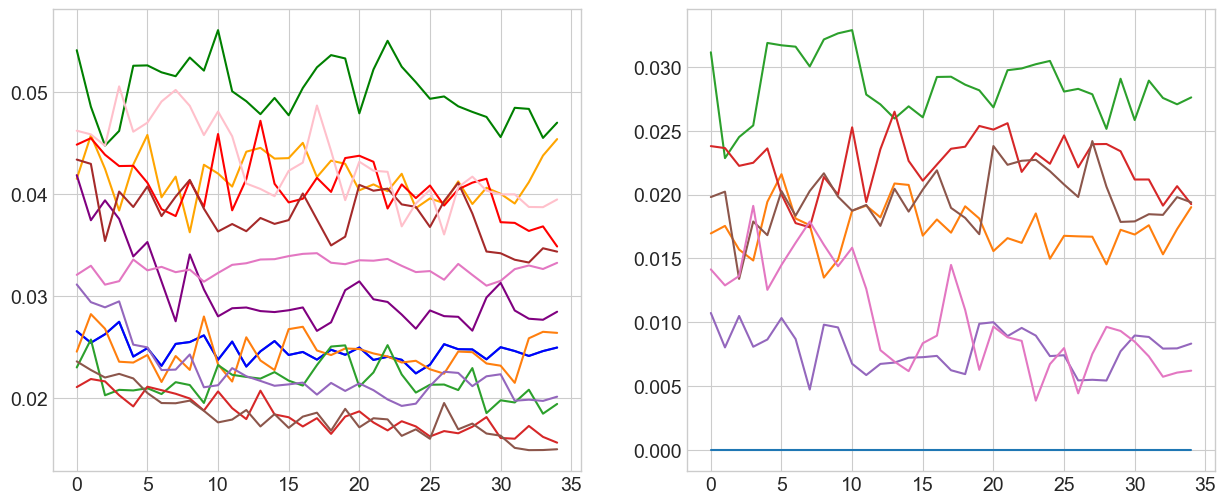

In [25]:
plt.figure(figsize=(15,6))
for mo in interactions.keys():
    plt.subplot(1, 2, 1)
    values = gaussian_filter1d((emd[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    values = gaussian_filter1d((ideal_emd[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo][4:])
    plt.subplot(1, 2, 2)
    values = gaussian_filter1d((ideal_emd[mo] - emd[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
plt.show()

In [35]:
# 100 iters, 16 pares, ~8hrs de ejecución
lsa = dict()
ideal_lsa = dict()
for mo in interactions.keys():
    lsa[mo] = []
    ideal_lsa[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        re2 = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_attrs_ideal = item_attrs[i].T[interactions['ideal'][i]]
        for j in range(0, user_iter_attrs.shape[1], 2):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            ideal_mean_user_attrs = user_iter_attrs_ideal[:,:(j+1)].mean(axis=1)
            nearest_users = get_sim_users_pairs(mean_user_attrs)
            lsa_iter = 0
            ideal_lsa_iter = 0
            print("Model:", mo, " sim:", i," iter:", (j+1))
            for p in nearest_users[:16]:
                d = compute_distance_matrix(user_iter_attrs[p[0],:(j+1)], user_iter_attrs[p[1],:(j+1)])
                f_row, f_col = linear_sum_assignment(d)
                lsa_iter += (d[f_row, f_col].sum() / (j+1)) / len(nearest_users[:16])

                ideal_d = compute_distance_matrix(user_iter_attrs_ideal[p[0],:(j+1)], user_iter_attrs_ideal[p[1],:(j+1)])
                ideal_f_row, ideal_f_col = linear_sum_assignment(ideal_d)
                ideal_lsa_iter += (ideal_d[ideal_f_row, ideal_f_col].sum() / (j+1)) / len(nearest_users[:16])
            re.append(lsa_iter)
            re2.append(ideal_lsa_iter)
        lsa[mo].append(re)
        ideal_lsa[mo].append(re2)
    lsa[mo] = np.array(lsa[mo])
    ideal_lsa[mo] = np.array(ideal_lsa[mo])

Model: ideal  sim: 0  iter: 1
Model: ideal  sim: 0  iter: 3
Model: ideal  sim: 0  iter: 5
Model: ideal  sim: 0  iter: 7
Model: ideal  sim: 0  iter: 9
Model: ideal  sim: 0  iter: 11
Model: ideal  sim: 0  iter: 13
Model: ideal  sim: 0  iter: 15
Model: ideal  sim: 0  iter: 17
Model: ideal  sim: 0  iter: 19
Model: ideal  sim: 0  iter: 21
Model: ideal  sim: 0  iter: 23
Model: ideal  sim: 0  iter: 25
Model: ideal  sim: 0  iter: 27
Model: ideal  sim: 0  iter: 29
Model: ideal  sim: 0  iter: 31
Model: ideal  sim: 0  iter: 33
Model: ideal  sim: 0  iter: 35
Model: ideal  sim: 0  iter: 37
Model: ideal  sim: 0  iter: 39
Model: ideal  sim: 0  iter: 41
Model: ideal  sim: 0  iter: 43
Model: ideal  sim: 0  iter: 45
Model: ideal  sim: 0  iter: 47
Model: ideal  sim: 0  iter: 49
Model: ideal  sim: 0  iter: 51
Model: ideal  sim: 0  iter: 53
Model: ideal  sim: 0  iter: 55
Model: ideal  sim: 0  iter: 57
Model: ideal  sim: 0  iter: 59
Model: ideal  sim: 0  iter: 61
Model: ideal  sim: 0  iter: 63
Model: ideal 

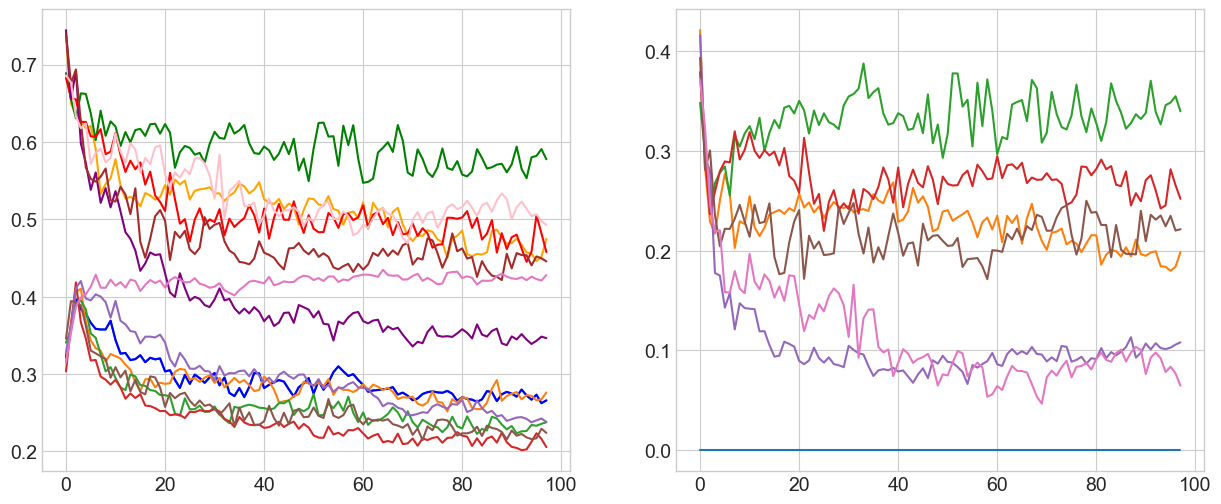

In [37]:
plt.figure(figsize=(15,6))
for mo in interactions.keys():
    plt.subplot(1, 2, 1)
    values = gaussian_filter1d((lsa[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[2:], color=colors[mo])
    values = gaussian_filter1d((ideal_lsa[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[2:], color=colors[mo][4:])
    plt.subplot(1, 2, 2)
    values = gaussian_filter1d((ideal_lsa[mo] - lsa[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[2:], color=colors[mo])
plt.show()

In [29]:
chamfer = dict()
ideal_chamfer = dict()
for mo in interactions.keys():
    chamfer[mo] = []
    ideal_chamfer[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        re2 = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_attrs_ideal = item_attrs[i].T[interactions['ideal'][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            ideal_mean_user_attrs = user_iter_attrs_ideal[:,:(j+1)].mean(axis=1)
            nearest_users = get_sim_users_pairs(mean_user_attrs)
            chamfer_iter = 0
            ideal_chamfer_iter = 0
            print("Model:", mo, " sim:", i," iter:", (j+1))
            for p in nearest_users:
                d = compute_distance_matrix(user_iter_attrs[p[0],:(j+1)], user_iter_attrs[p[1],:(j+1)])
                chamfer_iter += (d.min(axis=1).mean() + d.min(axis=0).mean()) / (2*len(nearest_users))

                ideal_d = compute_distance_matrix(user_iter_attrs_ideal[p[0],:(j+1)], user_iter_attrs_ideal[p[1],:(j+1)])
                ideal_chamfer_iter += (ideal_d.min(axis=1).mean() + ideal_d.min(axis=0).mean()) / (2*len(nearest_users))
            re.append(chamfer_iter)
            re2.append(ideal_chamfer_iter)
        chamfer[mo].append(re)
        ideal_chamfer[mo].append(re2)
    chamfer[mo] = np.array(chamfer[mo])
    ideal_chamfer[mo] = np.array(ideal_chamfer[mo])

Model: ideal  sim: 0  iter: 1
Model: ideal  sim: 0  iter: 2
Model: ideal  sim: 0  iter: 3
Model: ideal  sim: 0  iter: 4
Model: ideal  sim: 0  iter: 5
Model: ideal  sim: 0  iter: 6
Model: ideal  sim: 0  iter: 7
Model: ideal  sim: 0  iter: 8
Model: ideal  sim: 0  iter: 9
Model: ideal  sim: 0  iter: 10
Model: ideal  sim: 0  iter: 11
Model: ideal  sim: 0  iter: 12
Model: ideal  sim: 0  iter: 13
Model: ideal  sim: 0  iter: 14
Model: ideal  sim: 0  iter: 15
Model: ideal  sim: 0  iter: 16
Model: ideal  sim: 0  iter: 17
Model: ideal  sim: 0  iter: 18
Model: ideal  sim: 0  iter: 19
Model: ideal  sim: 0  iter: 20
Model: ideal  sim: 0  iter: 21
Model: ideal  sim: 0  iter: 22
Model: ideal  sim: 0  iter: 23
Model: ideal  sim: 0  iter: 24
Model: ideal  sim: 0  iter: 25
Model: ideal  sim: 0  iter: 26
Model: ideal  sim: 0  iter: 27
Model: ideal  sim: 0  iter: 28
Model: ideal  sim: 0  iter: 29
Model: ideal  sim: 0  iter: 30
Model: ideal  sim: 0  iter: 31
Model: ideal  sim: 0  iter: 32
Model: ideal  sim

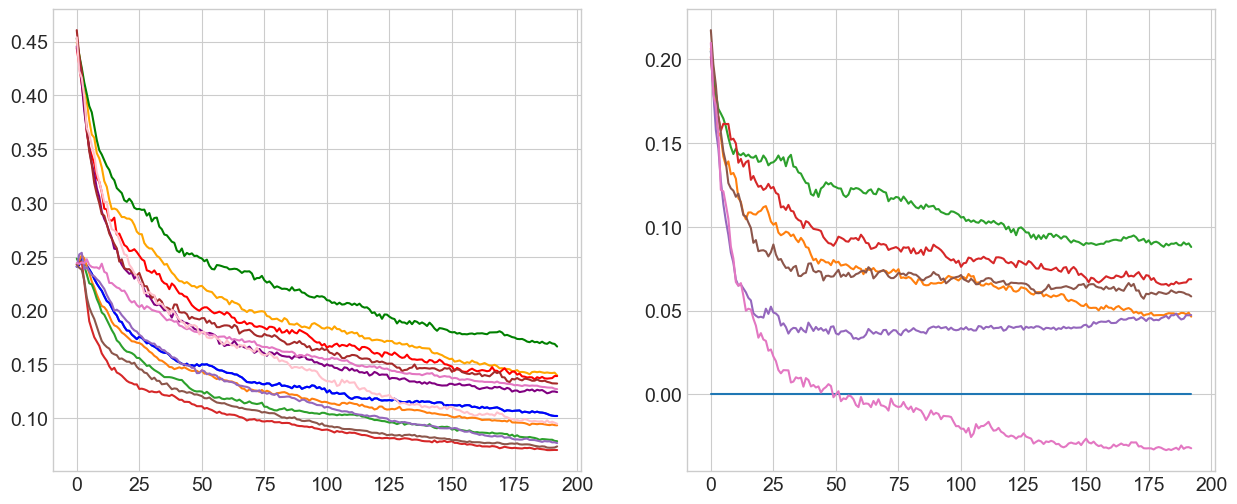

In [100]:
plt.figure(figsize=(15,6))
for mo in interactions.keys():
    plt.subplot(1, 2, 1)
    values = gaussian_filter1d((chamfer[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[7:], color=colors[mo])
    values = gaussian_filter1d((ideal_chamfer[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[7:], color=colors[mo][4:])
    plt.subplot(1, 2, 2)
    values = gaussian_filter1d((ideal_chamfer[mo] - chamfer[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[7:], color=colors[mo])
plt.show()

In [24]:
silh = dict()
ideal_silh = dict()
for mo in interactions.keys():
    silh[mo] = []
    ideal_silh[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        re2 = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_attrs_ideal = item_attrs[i].T[interactions['ideal'][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            ideal_mean_user_attrs = user_iter_attrs_ideal[:,:(j+1)].mean(axis=1)
            nearest_users = get_sim_users_pairs(mean_user_attrs)
            silh_iter = 0
            ideal_silh_iter = 0
            print("Model:", mo, " sim:", i," iter:", (j+1))
            for p in nearest_users:
                d = compute_distance_matrix(user_iter_attrs[p[0],:(j+1)], user_iter_attrs[p[1],:(j+1)])
                o0 = compute_distance_matrix(user_iter_attrs[p[0],:(j+1)], user_iter_attrs[p[0],:(j+1)])
                o1 = compute_distance_matrix(user_iter_attrs[p[1],:(j+1)], user_iter_attrs[p[1],:(j+1)])
                o0mean = o0.sum(axis=1)/(o0.shape[1]-1)
                o1mean = o1.sum(axis=1)/(o1.shape[1]-1)
                p0_silh = ((d.mean(axis=1) - o0mean)/np.maximum(d.mean(axis=1), o0mean)).mean()
                p1_silh = ((d.mean(axis=0) - o1mean)/np.maximum(d.mean(axis=0), o1mean)).mean()
                silh_iter += (p0_silh + p1_silh) / (2*len(nearest_users))

                d = compute_distance_matrix(user_iter_attrs_ideal[p[0],:(j+1)], user_iter_attrs_ideal[p[1],:(j+1)])
                o0 = compute_distance_matrix(user_iter_attrs_ideal[p[0],:(j+1)], user_iter_attrs_ideal[p[0],:(j+1)])
                o1 = compute_distance_matrix(user_iter_attrs_ideal[p[1],:(j+1)], user_iter_attrs_ideal[p[1],:(j+1)])
                o0mean = o0.sum(axis=1)/(o0.shape[1]-1)
                o1mean = o1.sum(axis=1)/(o1.shape[1]-1)
                p0_silh = ((d.mean(axis=1) - o0mean)/np.maximum(d.mean(axis=1), o0mean)).mean()
                p1_silh = ((d.mean(axis=0) - o1mean)/np.maximum(d.mean(axis=0), o1mean)).mean()
                ideal_silh_iter += (p0_silh + p1_silh) / (2*len(nearest_users))
            re.append(silh_iter)
            re2.append(ideal_silh_iter)
        silh[mo].append(re)
        ideal_silh[mo].append(re2)
    silh[mo] = np.array(silh[mo])
    ideal_silh[mo] = np.array(ideal_silh[mo])

Model: ideal  sim: 0  iter: 1
Model: ideal  sim: 0  iter: 2
Model: ideal  sim: 0  iter: 3
Model: ideal  sim: 0  iter: 4
Model: ideal  sim: 0  iter: 5
Model: ideal  sim: 0  iter: 6
Model: ideal  sim: 0  iter: 7
Model: ideal  sim: 0  iter: 8
Model: ideal  sim: 0  iter: 9
Model: ideal  sim: 0  iter: 10
Model: ideal  sim: 0  iter: 11
Model: ideal  sim: 0  iter: 12
Model: ideal  sim: 0  iter: 13
Model: ideal  sim: 0  iter: 14
Model: ideal  sim: 0  iter: 15
Model: ideal  sim: 0  iter: 16
Model: ideal  sim: 0  iter: 17
Model: ideal  sim: 0  iter: 18
Model: ideal  sim: 0  iter: 19
Model: ideal  sim: 0  iter: 20
Model: ideal  sim: 0  iter: 21
Model: ideal  sim: 0  iter: 22
Model: ideal  sim: 0  iter: 23
Model: ideal  sim: 0  iter: 24
Model: ideal  sim: 0  iter: 25
Model: ideal  sim: 0  iter: 26
Model: ideal  sim: 0  iter: 27
Model: ideal  sim: 0  iter: 28
Model: ideal  sim: 0  iter: 29
Model: ideal  sim: 0  iter: 30
Model: ideal  sim: 0  iter: 31
Model: ideal  sim: 0  iter: 32
Model: ideal  sim

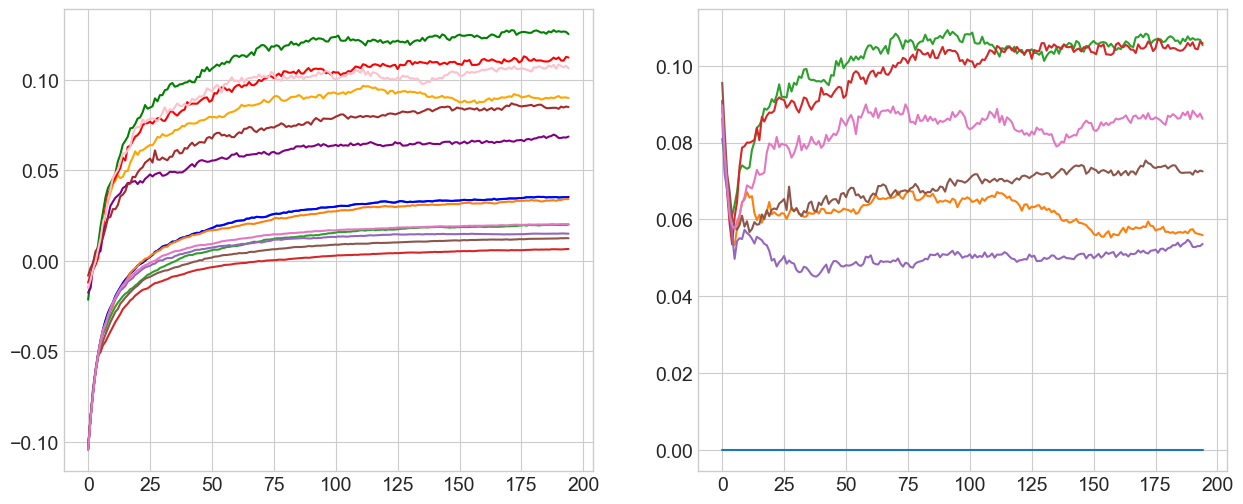

In [27]:
plt.figure(figsize=(15,6))
for mo in interactions.keys():
    plt.subplot(1, 2, 1)
    values = gaussian_filter1d((silh[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    values = gaussian_filter1d((ideal_silh[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo][4:])
    plt.subplot(1, 2, 2)
    values = gaussian_filter1d((ideal_silh[mo] - silh[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
plt.show()

In [31]:
random_chamfer = dict()
ideal_random_chamfer = dict()
for mo in interactions.keys():
    random_chamfer[mo] = []
    ideal_random_chamfer[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        re2 = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_attrs_ideal = item_attrs[i].T[interactions['ideal'][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            ideal_mean_user_attrs = user_iter_attrs_ideal[:,:(j+1)].mean(axis=1)
            nearest_users = get_sim_users_pairs(np.zeros(mean_user_attrs.shape))
            random_chamfer_iter = 0
            ideal_random_chamfer_iter = 0
            print("Model:", mo, " sim:", i," iter:", (j+1))
            for p in nearest_users:
                d = compute_distance_matrix(user_iter_attrs[p[0],:(j+1)], user_iter_attrs[p[1],:(j+1)])
                random_chamfer_iter += (d.min(axis=1).mean() + d.min(axis=0).mean()) / (2*len(nearest_users))

                ideal_d = compute_distance_matrix(user_iter_attrs_ideal[p[0],:(j+1)], user_iter_attrs_ideal[p[1],:(j+1)])
                ideal_random_chamfer_iter += (ideal_d.min(axis=1).mean() + ideal_d.min(axis=0).mean()) / (2*len(nearest_users))
            re.append(random_chamfer_iter)
            re2.append(ideal_random_chamfer_iter)
        random_chamfer[mo].append(re)
        ideal_random_chamfer[mo].append(re2)
    random_chamfer[mo] = np.array(random_chamfer[mo])
    ideal_random_chamfer[mo] = np.array(ideal_random_chamfer[mo])

Model: ideal  sim: 0  iter: 1
Model: ideal  sim: 0  iter: 2
Model: ideal  sim: 0  iter: 3
Model: ideal  sim: 0  iter: 4
Model: ideal  sim: 0  iter: 5
Model: ideal  sim: 0  iter: 6
Model: ideal  sim: 0  iter: 7
Model: ideal  sim: 0  iter: 8
Model: ideal  sim: 0  iter: 9
Model: ideal  sim: 0  iter: 10
Model: ideal  sim: 0  iter: 11
Model: ideal  sim: 0  iter: 12
Model: ideal  sim: 0  iter: 13
Model: ideal  sim: 0  iter: 14
Model: ideal  sim: 0  iter: 15
Model: ideal  sim: 0  iter: 16
Model: ideal  sim: 0  iter: 17
Model: ideal  sim: 0  iter: 18
Model: ideal  sim: 0  iter: 19
Model: ideal  sim: 0  iter: 20
Model: ideal  sim: 0  iter: 21
Model: ideal  sim: 0  iter: 22
Model: ideal  sim: 0  iter: 23
Model: ideal  sim: 0  iter: 24
Model: ideal  sim: 0  iter: 25
Model: ideal  sim: 0  iter: 26
Model: ideal  sim: 0  iter: 27
Model: ideal  sim: 0  iter: 28
Model: ideal  sim: 0  iter: 29
Model: ideal  sim: 0  iter: 30
Model: ideal  sim: 0  iter: 31
Model: ideal  sim: 0  iter: 32
Model: ideal  sim

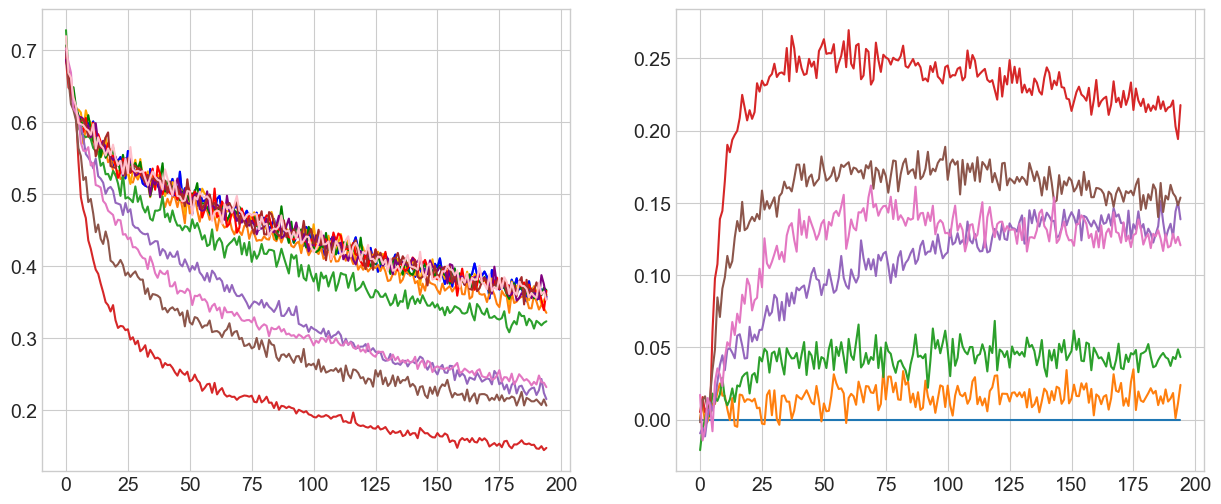

In [32]:
plt.figure(figsize=(15,6))
for mo in interactions.keys():
    plt.subplot(1, 2, 1)
    values = gaussian_filter1d((random_chamfer[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    values = gaussian_filter1d((ideal_random_chamfer[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo][4:])
    plt.subplot(1, 2, 2)
    values = gaussian_filter1d((ideal_random_chamfer[mo] - random_chamfer[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
plt.show()

## Comparando

In [56]:
sim_colors = ["#7F01B7", "#0754B1", "#93A29B", "#FF051D", "#ECF311", "#66B800"]

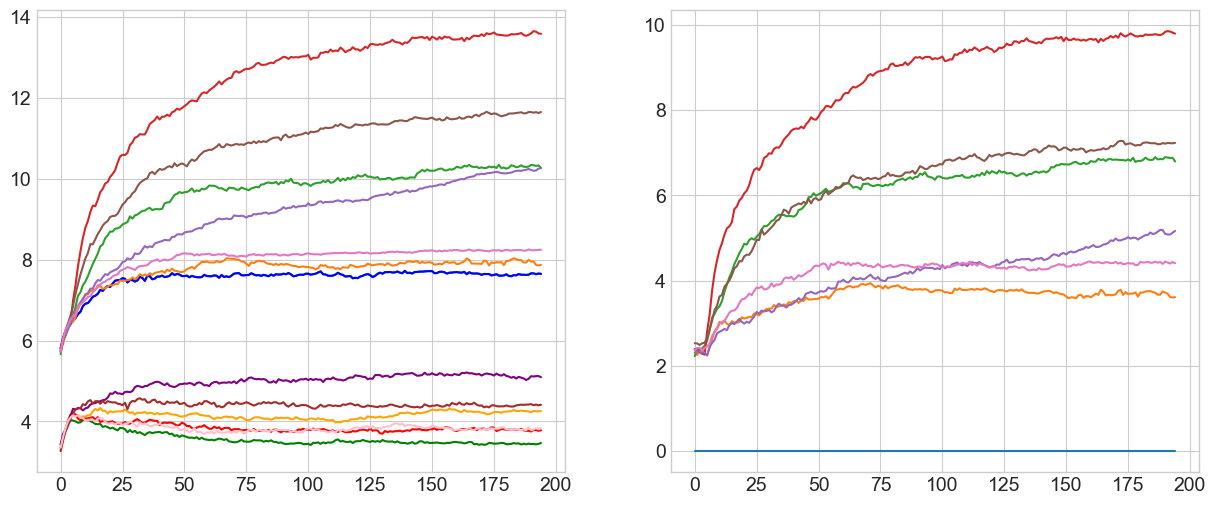

In [43]:
plt.figure(figsize=(15,6))
for mo in interactions.keys():
    plt.subplot(1, 2, 1)
    values = gaussian_filter1d((intra_MRMSD[mo] / inter_RMSD[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    values = gaussian_filter1d((ideal_intra_MRMSD[mo] / ideal_inter_RMSD[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo][4:])
    plt.subplot(1, 2, 2)
    values = gaussian_filter1d((-(ideal_intra_MRMSD[mo] / ideal_inter_RMSD[mo]) + (intra_MRMSD[mo] / inter_RMSD[mo])).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
plt.show()

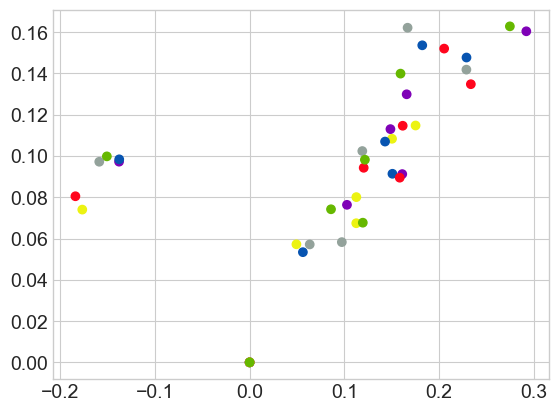

In [103]:
for mo in interactions.keys():
    m0 = (ideal_inter_RMSD[mo] - inter_RMSD[mo])
    m1 = (mean_Jacc_sim[mo] - ideal_mean_Jacc_sim[mo])
    m2 = (ideal_lsa[mo] - lsa[mo])
    x_values = m1[:,-2]
    y_values = m0[:,-2]
    plt.scatter(x_values, y_values, c=sim_colors)
plt.show()

Did I just struck gold?\
RMSD se parece a Jaccard lo suficiente, LSA se parece a Jaccard bastante, pero RMSD y LSA no se parecen tanto entre sí.\
En cada simulación los resultados de RMSD y Jacc son proporcionales, same con LSA y Jacc, la tendencia es bastante positiva para ambos siempre. Pero a la hora de comparar RMSD y LSA los resultados se desparraman. Sí, hay una tendencia positiva en cada simulación, pero no es fuerte. It's all over the place.

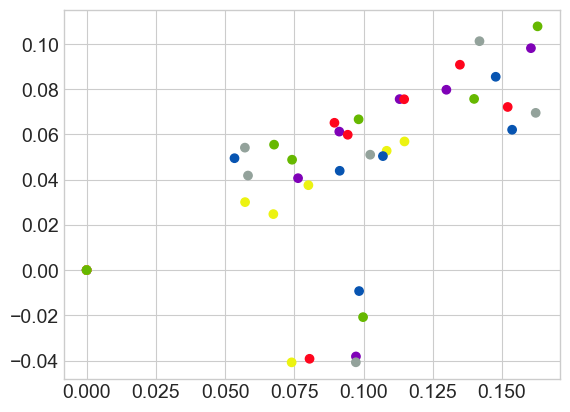

In [131]:
for mo in interactions.keys():
    m0 = (ideal_inter_RMSD[mo] - inter_RMSD[mo])
    m1 = (mean_Jacc_sim[mo] - ideal_mean_Jacc_sim[mo])
    m2 = (ideal_chamfer[mo] - chamfer[mo])
    m3 = (ideal_lsa[mo] - lsa[mo])
    x_values = m0[:,-2]
    y_values = m2[:,-2]
    plt.scatter(x_values, y_values, c=sim_colors)
plt.show()

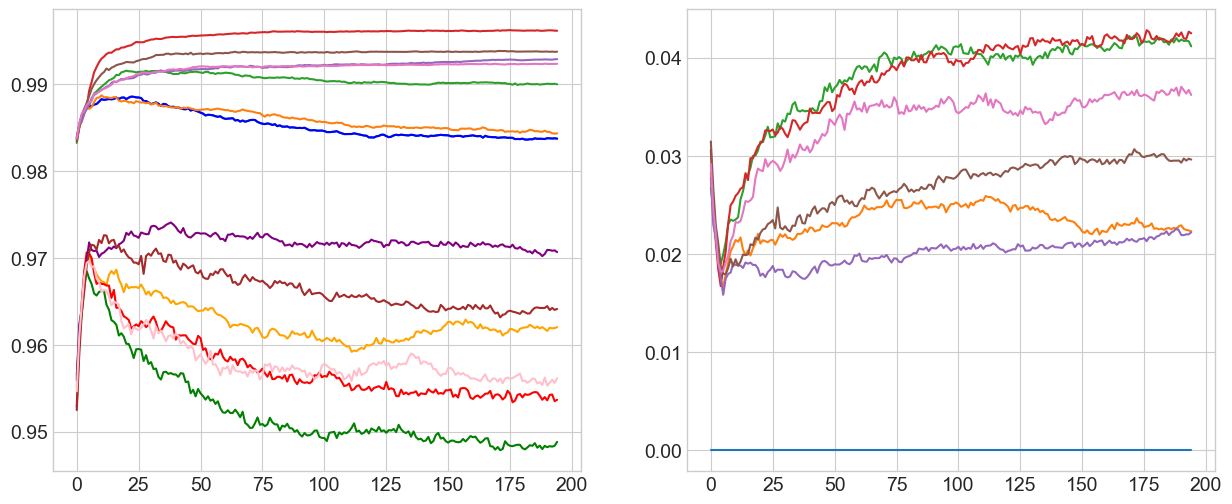

In [142]:
plt.figure(figsize=(15,6))
for mo in interactions.keys():
    plt.subplot(1, 2, 1)
    values = gaussian_filter1d((intra_MRMSD[mo] / intra_MRMSD_central[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    values = gaussian_filter1d((ideal_intra_MRMSD[mo] / ideal_intra_MRMSD_central[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo][4:])
    plt.subplot(1, 2, 2)
    values = gaussian_filter1d((-(ideal_intra_MRMSD[mo] / ideal_intra_MRMSD_central[mo]) + (intra_MRMSD[mo] / intra_MRMSD_central[mo])).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
plt.show()

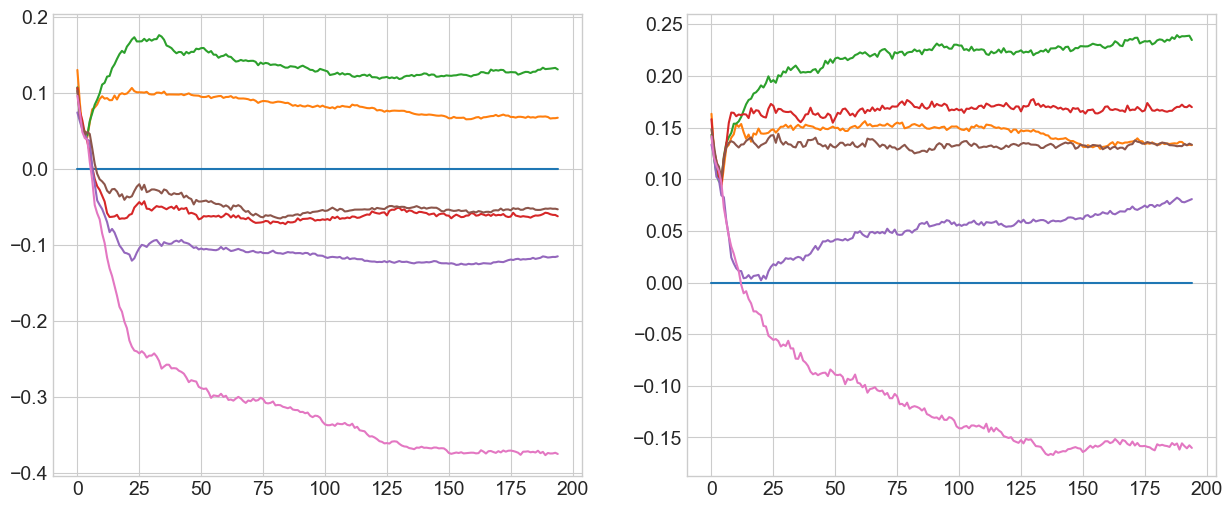

In [149]:
plt.figure(figsize=(15,6))
for mo in interactions.keys():
    plt.subplot(1, 2, 1)
    homog = 1. / (inter_RMSD[mo]**2 + intra_MRMSD[mo]**2)
    ideal_homog = 1. / (ideal_inter_RMSD[mo]**2 + ideal_intra_MRMSD[mo]**2)
    values = gaussian_filter1d((homog - ideal_homog).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    plt.subplot(1, 2, 2)
    values = gaussian_filter1d((mean_Jacc_sim[mo] - ideal_mean_Jacc_sim[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
plt.show()

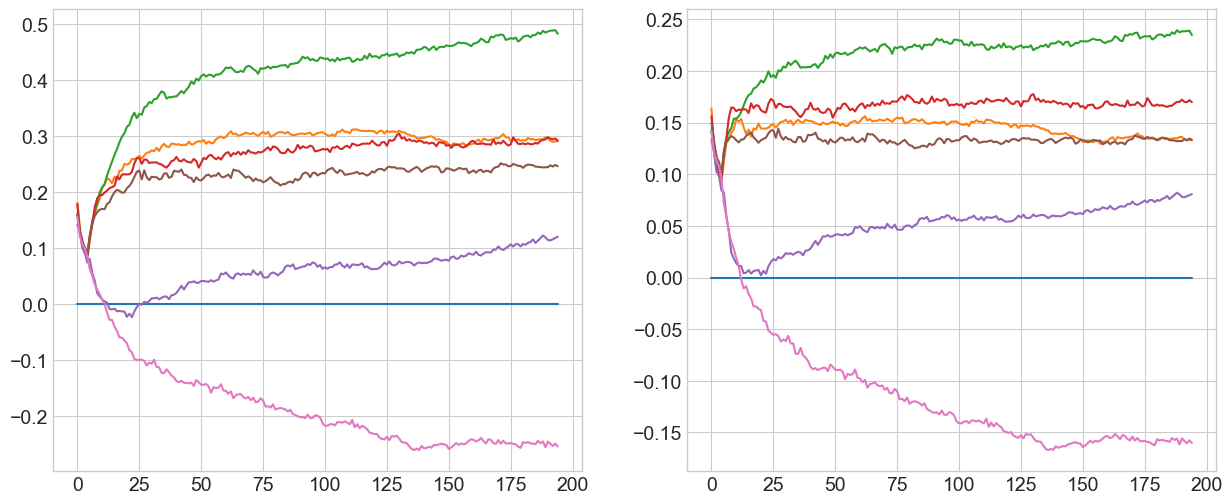

In [80]:
plt.figure(figsize=(15,6))
for mo in interactions.keys():
    plt.subplot(1, 2, 1)
    homog = overlap_index[mo]**2 / (inter_RMSD[mo]**2 + intra_MRMSD[mo]**2)
    ideal_homog = ideal_overlap_index[mo]**2 / (ideal_inter_RMSD[mo]**2 + ideal_intra_MRMSD[mo]**2)
    values = gaussian_filter1d((homog - ideal_homog).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    plt.subplot(1, 2, 2)
    values = gaussian_filter1d((mean_Jacc_sim[mo] - ideal_mean_Jacc_sim[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
plt.show()

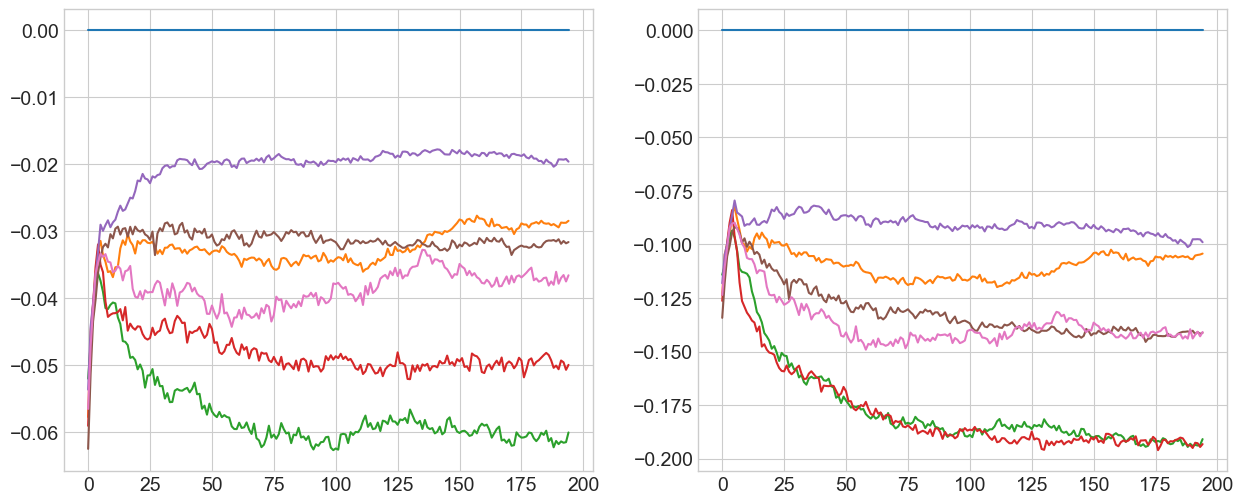

In [154]:
plt.figure(figsize=(15,6))
for mo in interactions.keys():
    plt.subplot(1, 2, 1)
    fbe = inter_RMSD[mo]**2 / (overlap_index[mo]**2 + intra_MRMSD[mo]**2)
    ideal_fbe = ideal_inter_RMSD[mo]**2 / (ideal_overlap_index[mo]**2 + ideal_intra_MRMSD[mo]**2)
    values = gaussian_filter1d((-ideal_fbe + fbe).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    plt.subplot(1, 2, 2)
    fbe = inter_RMSD[mo] / intra_MRMSD[mo]
    ideal_fbe = ideal_inter_RMSD[mo] / ideal_intra_MRMSD[mo]
    values = gaussian_filter1d((-ideal_fbe + fbe).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
plt.show()

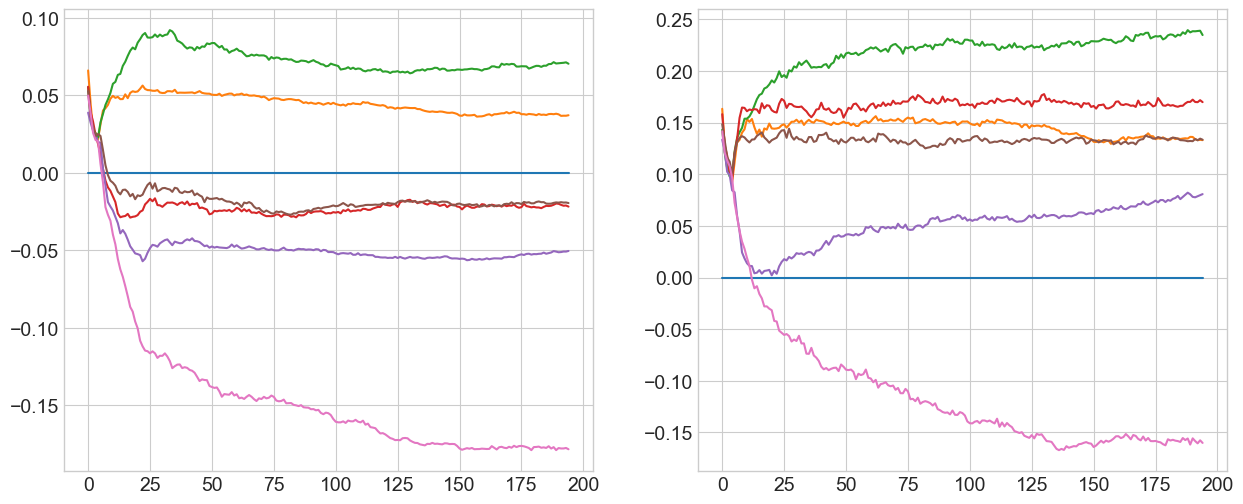

In [140]:
plt.figure(figsize=(15,6))
for mo in interactions.keys():
    plt.subplot(1, 2, 1)
    homog = 1. / (inter_RMSD[mo]**2 + intra_MRMSD[mo]**2 + intra_MRMSD_central[mo]**2)
    ideal_homog = 1. / (ideal_inter_RMSD[mo]**2 + ideal_intra_MRMSD[mo]**2 + ideal_intra_MRMSD_central[mo]**2)
    values = gaussian_filter1d((homog - ideal_homog).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    plt.subplot(1, 2, 2)
    values = gaussian_filter1d((mean_Jacc_sim[mo] - ideal_mean_Jacc_sim[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
plt.show()

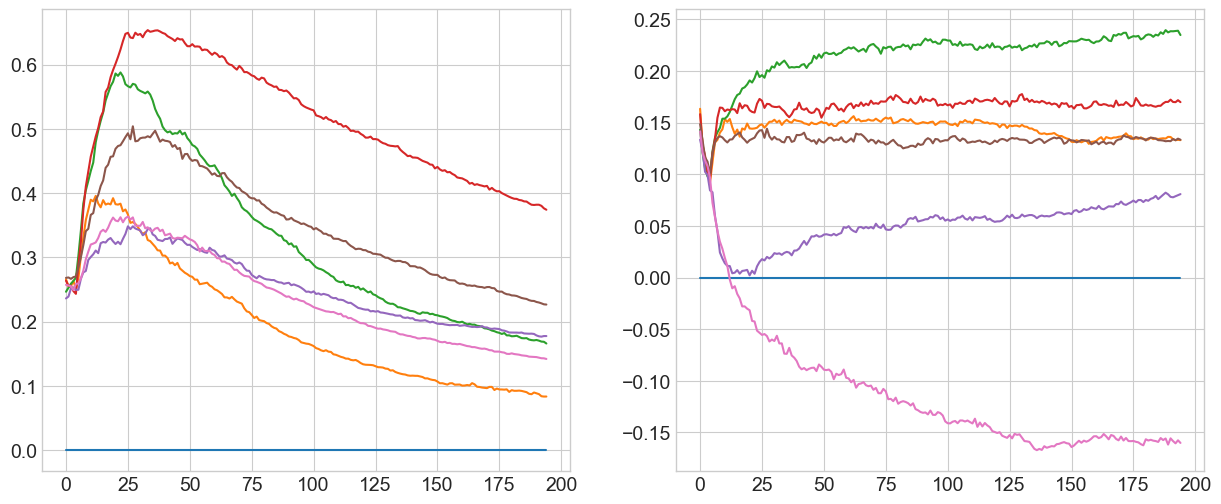

In [130]:
plt.figure(figsize=(15,6))
for mo in interactions.keys():
    plt.subplot(1, 2, 1)
    homog = 1. / (inter_WMSD_minus_one[mo] + intra_WCSS_normalized[mo])
    ideal_homog = 1. / (ideal_inter_WMSD_minus_one[mo] + ideal_intra_WCSS_normalized[mo])
    values = gaussian_filter1d((homog - ideal_homog).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    plt.subplot(1, 2, 2)
    values = gaussian_filter1d((mean_Jacc_sim[mo] - ideal_mean_Jacc_sim[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
plt.show()

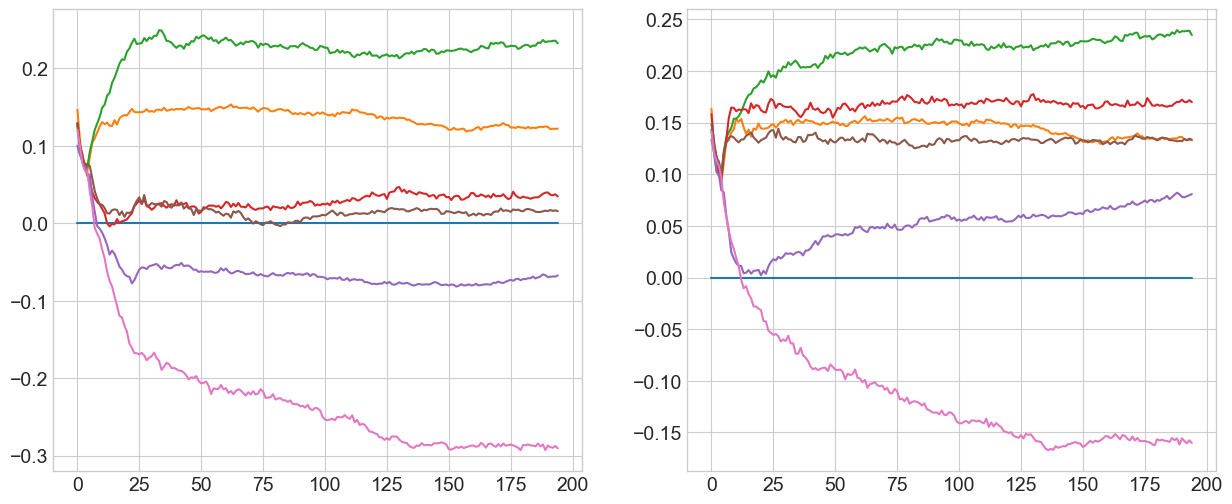

In [131]:
plt.figure(figsize=(15,6))
for mo in interactions.keys():
    plt.subplot(1, 2, 1)
    homog = 1. / (inter_RMSD_minus_one[mo]**2 + intra_MRMSD_minus_one[mo]**2)
    ideal_homog = 1. / (ideal_inter_RMSD_minus_one[mo]**2 + ideal_intra_MRMSD_minus_one[mo]**2)
    values = gaussian_filter1d((homog - ideal_homog).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    plt.subplot(1, 2, 2)
    values = gaussian_filter1d((mean_Jacc_sim[mo] - ideal_mean_Jacc_sim[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
plt.show()

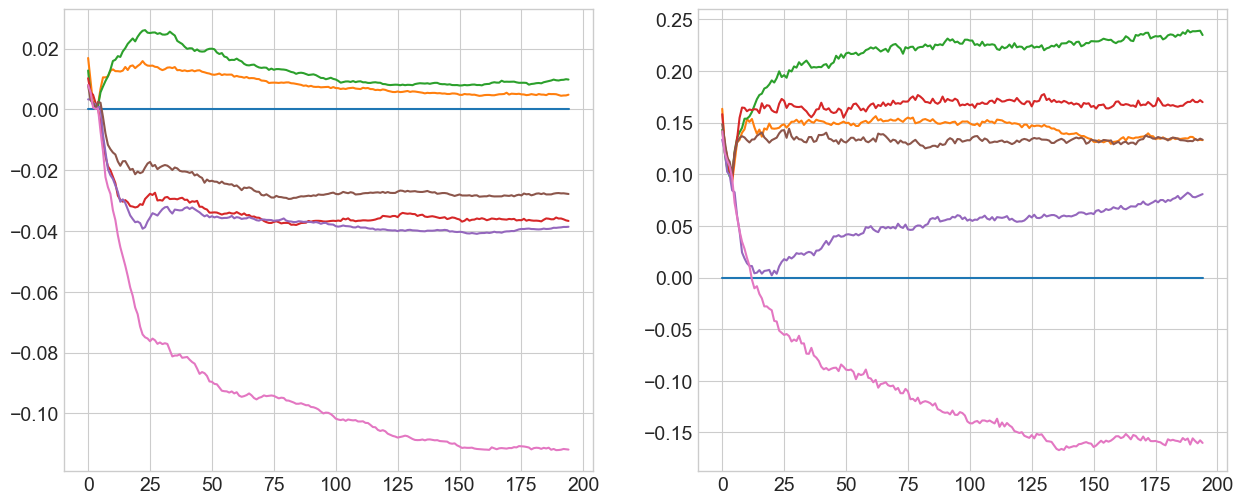

In [132]:
plt.figure(figsize=(15,6))
for mo in interactions.keys():
    plt.subplot(1, 2, 1)
    homog = 1. / (inter_RMSD[mo]**2 + intra_NRMSD[mo]**2)
    ideal_homog = 1. / (ideal_inter_RMSD[mo]**2 + ideal_intra_NRMSD[mo]**2)
    values = gaussian_filter1d((homog - ideal_homog).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    plt.subplot(1, 2, 2)
    values = gaussian_filter1d((mean_Jacc_sim[mo] - ideal_mean_Jacc_sim[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
plt.show()

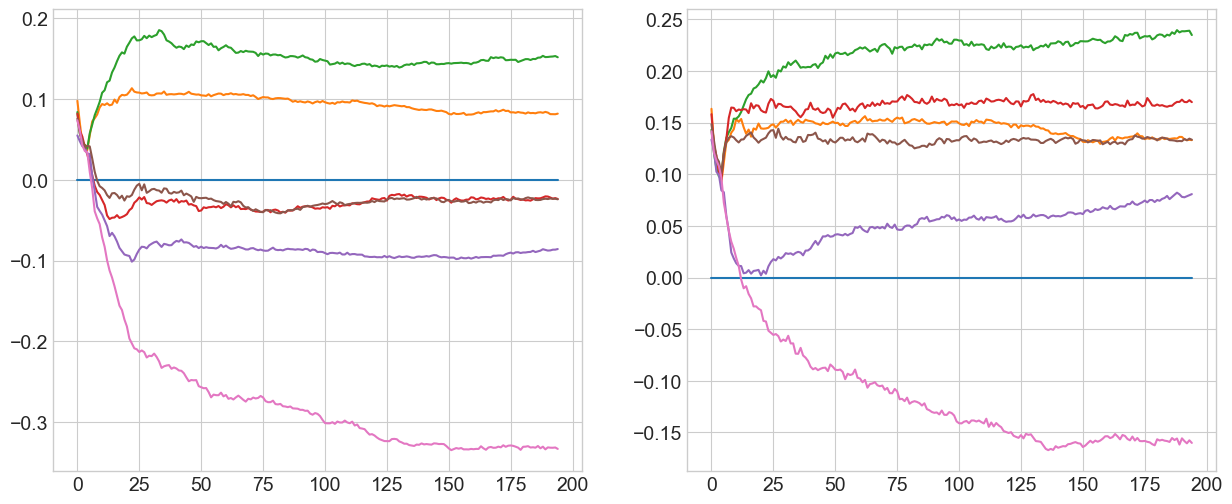

In [134]:
plt.figure(figsize=(15,6))
for mo in interactions.keys():
    plt.subplot(1, 2, 1)
    homog = 1. / (inter_MSD[mo] + intra_MMSD_minus_one[mo])
    ideal_homog = 1. / (ideal_inter_MSD[mo] + ideal_intra_MMSD_minus_one[mo])
    values = gaussian_filter1d((homog - ideal_homog).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    plt.subplot(1, 2, 2)
    values = gaussian_filter1d((mean_Jacc_sim[mo] - ideal_mean_Jacc_sim[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
plt.show()

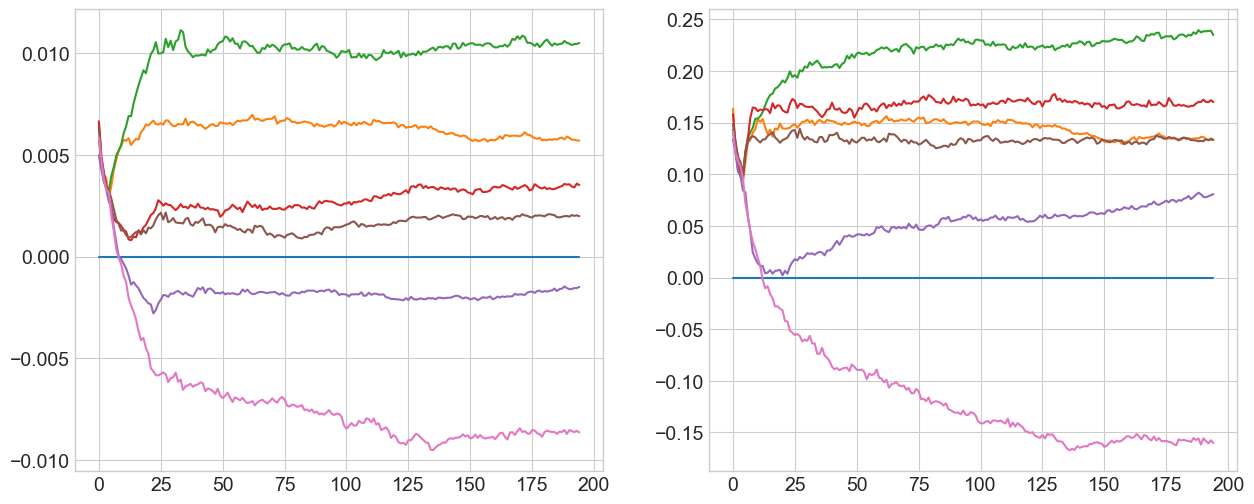

In [186]:
plt.figure(figsize=(15,6))
for mo in interactions.keys():
    plt.subplot(1, 2, 1)
    homog = 1. / (inter_RMSD[mo]**2 + intra_NRMSD[mo]**2 + (dissim_index[mo]/20)**2)
    ideal_homog = 1. / (ideal_inter_RMSD[mo]**2 + ideal_intra_NRMSD[mo]**2 + (ideal_dissim_index[mo]/20)**2)
    values = gaussian_filter1d((homog - ideal_homog).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    plt.subplot(1, 2, 2)
    values = gaussian_filter1d((mean_Jacc_sim[mo] - ideal_mean_Jacc_sim[mo]).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])

## Homogenización general

In [45]:
inter_gen = dict()
for mo in interactions.keys():
    inter_gen[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            user_mean = mean_user_attrs.mean(axis=0)
            distances = np.linalg.norm(mean_user_attrs - user_mean, axis=1)
            variance = ((distances**2).sum())/distances.shape[0]
            re.append(variance**0.5)
        inter_gen[mo].append(re)
    inter_gen[mo] = np.array(inter_gen[mo])

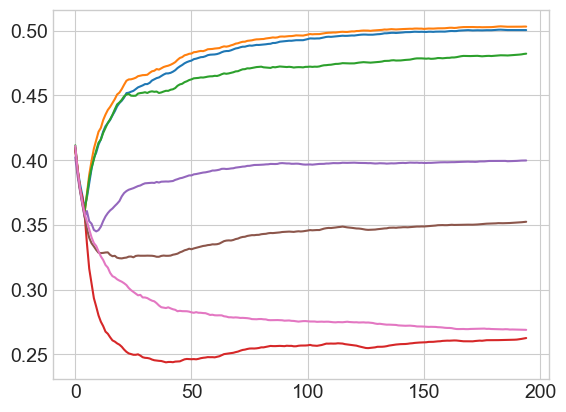

In [46]:
#plt.figure(figsize=(15,6))
for mo in interactions.keys():
    #plt.subplot(1, 2, 1)
    values = gaussian_filter1d(inter_gen[mo].mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    #plt.subplot(1, 2, 2)
    #values = gaussian_filter1d((mean_Jacc_sim[mo] - ideal_mean_Jacc_sim[mo]).mean(axis=0), sigma=0.1)
    #plt.plot(values[5:], color=colors[mo])
plt.show()

In [47]:
intra_gen = dict()
for mo in interactions.keys():
    intra_gen[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            diff_vectors = np.array([user_iter_attrs[k,:(j+1)] - mean_user_attrs[k] for k in range(user_iter_attrs.shape[0])])
            distances = np.linalg.norm(diff_vectors, axis=2)
            variances = ((distances**2).sum(axis=1))/distances.shape[1]
            re.append((variances**0.5).mean())
        intra_gen[mo].append(re)
    intra_gen[mo] = np.array(intra_gen[mo])

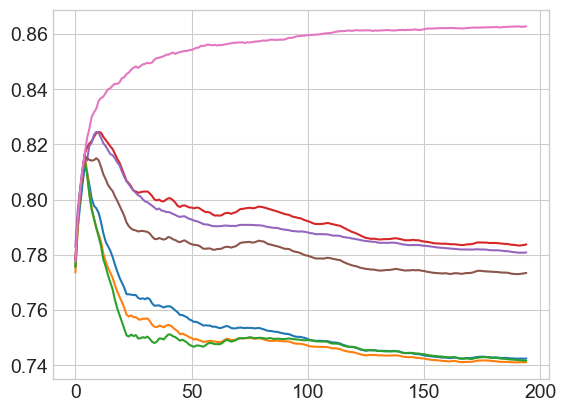

In [48]:
#plt.figure(figsize=(15,6))
for mo in interactions.keys():
    #plt.subplot(1, 2, 1)
    values = gaussian_filter1d(intra_gen[mo].mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    #plt.subplot(1, 2, 2)
    #values = gaussian_filter1d((mean_Jacc_sim[mo] - ideal_mean_Jacc_sim[mo]).mean(axis=0), sigma=0.1)
    #plt.plot(values[5:], color=colors[mo])
plt.show()

In [49]:
overlap_gen = dict()
for mo in interactions.keys():
    overlap_gen[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_indices = interactions[mo][i]
        for j in range(user_iter_indices.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            user_jiter_indices = user_iter_indices[:,:(j+1)]
            total_interactions = user_jiter_indices.shape[0]*(j+1)
            interacted_items = (np.bincount(user_jiter_indices.flatten()) > 0).sum()
            re.append((total_interactions - interacted_items) / interacted_items)
        overlap_gen[mo].append(re)
    overlap_gen[mo] = np.array(overlap_gen[mo])

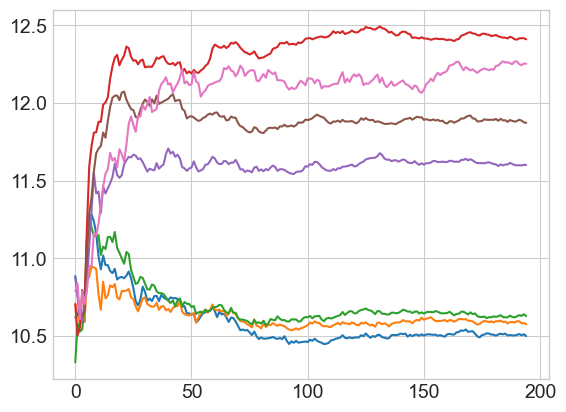

In [50]:
#plt.figure(figsize=(15,6))
for mo in interactions.keys():
    #plt.subplot(1, 2, 1)
    values = gaussian_filter1d(overlap_gen[mo].mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    #plt.subplot(1, 2, 2)
    #values = gaussian_filter1d((mean_Jacc_sim[mo] - ideal_mean_Jacc_sim[mo]).mean(axis=0), sigma=0.1)
    #plt.plot(values[5:], color=colors[mo])
plt.show()

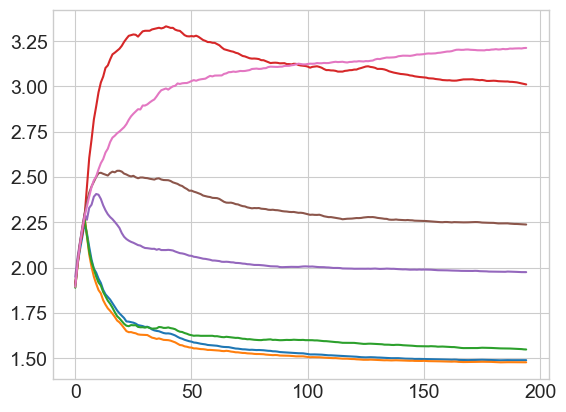

In [95]:
for mo in interactions.keys():
    #plt.subplot(1, 2, 1)
    fbe_inv = intra_gen[mo] / inter_gen[mo]
    values = gaussian_filter1d(fbe_inv.mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    #plt.subplot(1, 2, 2)
    #values = gaussian_filter1d((mean_Jacc_sim[mo] - ideal_mean_Jacc_sim[mo]).mean(axis=0), sigma=0.1)
    #plt.plot(values[5:], color=colors[mo])
plt.show()

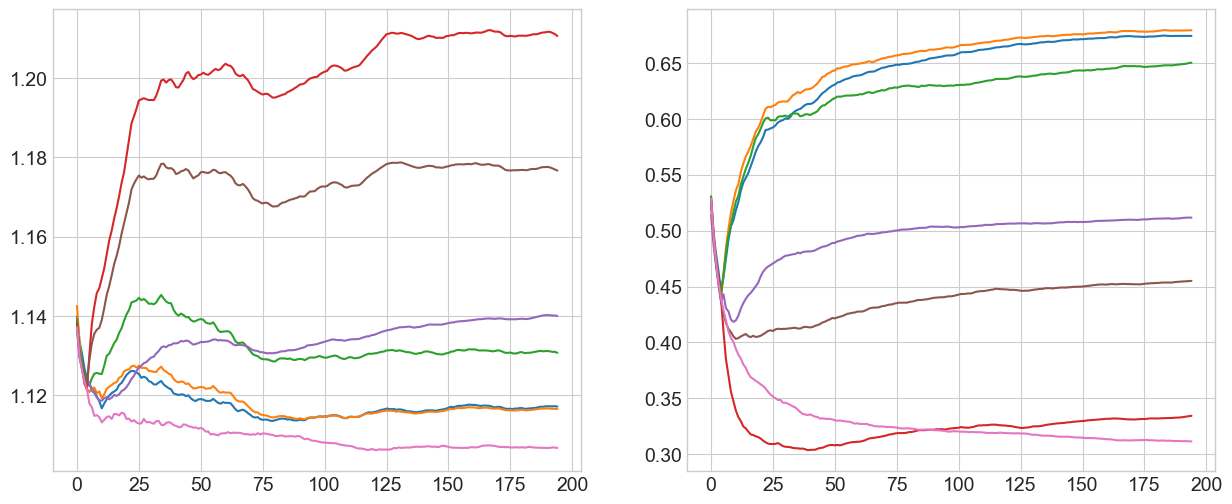

In [97]:
plt.figure(figsize=(15,6))
for mo in interactions.keys():
    plt.subplot(1, 2, 1)
    fbe = inter_gen[mo] / intra_gen[mo]
    homog = 1 / (inter_gen[mo]**2 + intra_gen[mo]**2)
    values = gaussian_filter1d((homog**0.5).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    plt.subplot(1, 2, 2)
    values = gaussian_filter1d(fbe.mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
plt.show()

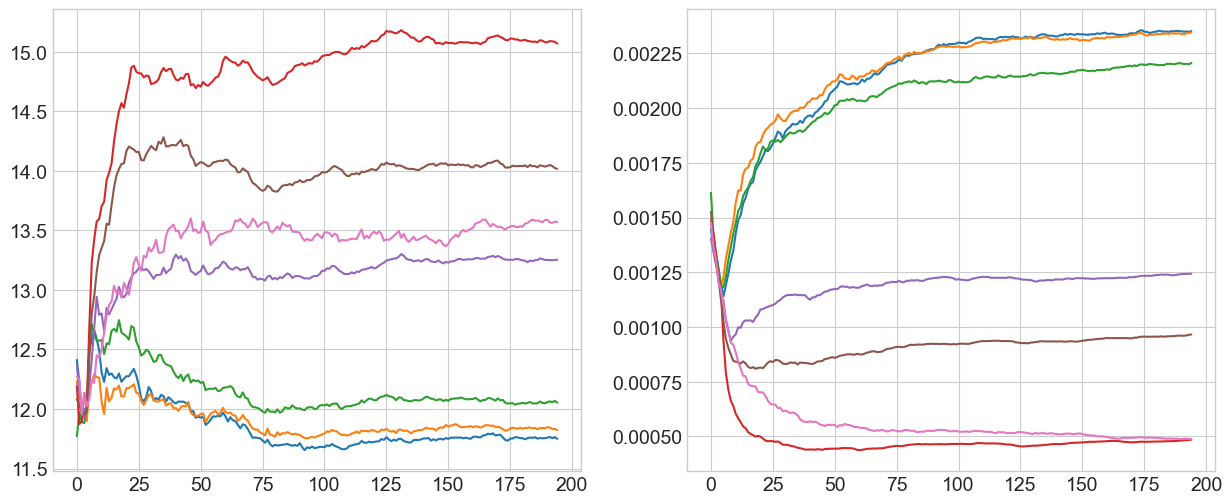

In [65]:
plt.figure(figsize=(15,6))
for mo in interactions.keys():
    plt.subplot(1, 2, 1)
    fbe = inter_gen[mo]**2 / (intra_gen[mo]**2 + overlap_gen[mo]**2)
    homog = overlap_gen[mo]**2 / (inter_gen[mo]**2 + intra_gen[mo]**2)
    values = gaussian_filter1d((homog**0.5).mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
    plt.subplot(1, 2, 2)
    values = gaussian_filter1d(fbe.mean(axis=0), sigma=0.1)
    plt.plot(values[5:], color=colors[mo])
plt.show()

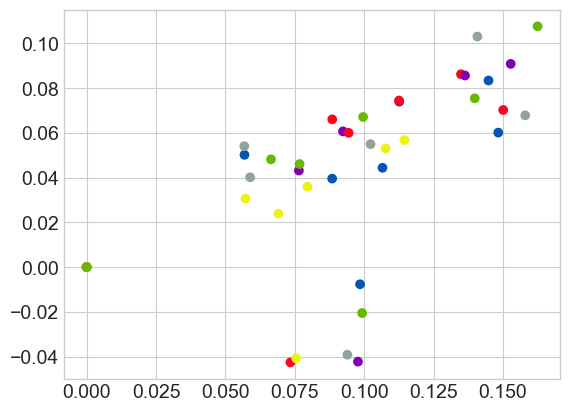

In [109]:
for mo in interactions.keys():
    m0 = (ideal_inter_RMSD[mo] - inter_RMSD[mo])
    m2 = (ideal_random_chamfer[mo] - random_chamfer[mo])
    m3 = (-(1 / (inter_gen["ideal"]**2 + intra_gen["ideal"]**2))+(1 / (inter_gen[mo]**2 + intra_gen[mo]**2)))
    m4 = overlap_gen[mo]

    homog = 1 / (inter_RMSD[mo]**2 + intra_MRMSD[mo]**2)
    ideal_homog = 1 / (ideal_inter_RMSD[mo]**2 + ideal_intra_MRMSD[mo]**2)
    m5 = homog - ideal_homog
    m6 = (ideal_chamfer[mo] - chamfer[mo])
    m7 = (ideal_inter_MSD[mo] - inter_MSD[mo])

    x_values = m0[:,-1]
    y_values = m6[:,-1]
    plt.scatter(x_values, y_values, c=sim_colors)
plt.show()